In [ ]:
# ST-FMR analysis

# Improvements list:
# -

# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import re
import os 
import glob
import sys
from pathlib import Path

folder = ".\Data"

# STFMR Class 1.1
class STFMR:
    def __init__(self, folder=None, filename=None, voltage_unit='uV', d_FM=None, d_NM=None, Ms=None, Width=None, Length=None, used_fields='Pos'):
        """
        Parameters
        ----------
        filename : str
            Path to data file
        """
        if folder is not None:
            self.folder = folder
        if filename is not None:
            self.filename = filename

        self.pattern = re.compile(
            r"Phi_(?P<phi>[+-]?\d+(?:\.\d+)?)deg_"
            r"Freq_(?P<freq>[+-]?\d+(?:\.\d+)?)GHz_"
            r"Pow_(?P<pow>[+-]?\d+(?:\.\d+)?)dBm_"
            r"Trace_(?P<trace>\d+)"
        )

        self.patternDC = re.compile(
            r"Phi_(?P<phi>[+-]?\d+(?:\.\d+)?)deg_"
            r"Freq_(?P<freq>[+-]?\d+(?:\.\d+)?)GHz_"
            r"Pow_(?P<pow>[+-]?\d+(?:\.\d+)?)dBm_"
            r"Curr_(?P<dc>[+-]?\d+(?:\.\d+)?)mA_"
            r"Trace_(?P<trace>\d+)"
        )

        # Physical constants
        self.mu_B = 9.274009994e-24  # Bohr magneton [J/T]
        self.e = 1.602176634e-19     # elementary charge [C]
        self.mu_0 = 4 * np.pi * 1e-7 # vacuum permeability [H/m]
        self.gamma = 1.760859e11     # gyromagnetic ratio [rad/(s·T)]
        self.hbar = 6.626e-34

        # System settings
        self.voltage_unit = voltage_unit  
        self.d_FM = d_FM
        self.d_NM = d_NM
        self.Ms = Ms
        self.Width = Width
        self.Lenght = Length
        self.used_fields=used_fields
        # self.remove_symmetric = remove_symmetric #In principle not necessary, if you look at used_fields which could also be 'Both'

    # -----------Data loading and preprocessing-----------
    def get_key(self, filepath):
        """Create a key for a file, which describes the most important parameters of the datafile. Distinghuishes between measurement with or without DC."""
        filename = Path(filepath).name
        if 'Curr' in filename:
            # print('filename:', filename)
            match = self.patternDC.search(filename)
            # print('Pattern:', self.patternDC)
            # print('match:', match)
            if match:
                phi, freq, pow_, dc, trace = match.groups()
                return (phi, freq, pow_, dc, trace)
            return None
        
        else:
            # print('filename:', filename)
            match = self.pattern.search(filename)
            # print('Pattern:', self.pattern)
            # print('match:', match)
            if match:
                phi, freq, pow_, trace = match.groups()
                return (phi, freq, pow_, trace)
            return None
    
    def group_files(self):
        """Groups files based on their key. Will be performed for the inputted folder in the class. """
        grouped_files = {}
        for filename in os.listdir(self.folder):
            if filename.lower().endswith(".txt"): 
                if 'Curr' in filename:
                    (phi, freq, pow_, dc, trace) = self.get_key(filename)
                    key = (phi, freq, pow_, dc)
                else:           
                    (phi, freq, pow_, trace) = self.get_key(filename)
                    key = (phi, freq, pow_)
                grouped_files.setdefault(key, []).append(filename)
            # print(grouped_files)
        return grouped_files

    def parse_resistance(self, first_line):
        # Look for "R = 93.6 Ohm" with flexible spaces
        match = re.search(r"R\s*=\s*([0-9.]+)\s*Ohm", first_line)
        if match:
            return float(match.group(1))
        else:
            raise ValueError(f"Could not parse resistance from line: '{first_line}'")
        
    def read_file(self, filepath):
         # Read the resistance value from the first line
        with open(filepath, 'r') as f:
            first_line = f.readline().strip()

        # Extract resistance value (assuming format 'R =93.6Ohm')
        R = self.parse_resistance(first_line)

        # Read the actual data starting from the second line
        df = pd.read_csv(filepath, sep='\t', skiprows=1, header=0)

        if self.voltage_unit == 'uV':
            df['Vx'] *= 1e6  # Convert Vx to microvolts
            df['Vy'] *= 1e6  # Convert Vy to microvolts
        elif self.voltage_unit == 'mV':
            df['Vx'] *= 1e3  # Convert Vx to millivolts
            df['Vy'] *= 1e3  # Convert Vy to millivolts

        # Make a copy of the magnitude column
        df["H_signed"] = df["H_mag"]
        H = df["H_given"].to_numpy()
        H_signed = H.copy()
        idx_half = len(H) // 2

        # Case 1: symmetric sweep (e.g. 2,1,0,1,2) 
        if abs(H[0]) == abs(H[-1]):
            # print("Detected symmetric sweep: multiplying first half with -1.")
            df.loc[:idx_half, "H_signed"] *= -1
            if self.used_fields == 'Neg':
                # Keep only positive fields
                df = df.iloc[:idx_half+1].reset_index(drop=True)
            elif self.used_fields == 'Pos':
                # Keep only negative fields
                df = df.iloc[idx_half:].reset_index(drop=True)
            elif self.used_fields == 'Both':
                df.loc[:idx_half, "H_signed"] *= -1
            return R, df

        # Case 2: monotonic positive sweep (e.g. 0,1,2)
        else:
            # print("Detected positive-only sweep: kept fields as it is.")
            return R, df

    def plot_traces(self):
        # Check for set folder or filename. Then extract data and plot
        if self.folder is not None:
            grouped_files = self.group_files()

            fig, ax = plt.subplots(len(grouped_files), 1, figsize=(8, 11*len(grouped_files)))
            for i, (key, files) in enumerate(grouped_files.items()):
                for f in files:
                    path = os.path.join(self.folder, f)
                    if 'Curr' in f:
                        (phi, freq, pow_, dc, trace) = self.get_key(f)
                        ax[i].set_title(f"Phi={phi}deg\nFreq={freq}GHz\nPow={pow_}dBm\nDC={dc}\nTrace={trace}")
                    else:
                        (phi, freq, pow_, trace) = self.get_key(f)
                        ax[i].set_title(f"Phi={phi}deg\nFreq={freq}GHz\nPow={pow_}dBm\nTrace={trace}")
                    R, df = self.read_file(path)
                    # PLOT FUNCTION
                    ax[i].plot(df["H_signed"], df["Vx"], '.', label=f"Trace {trace}")
                    ax[i].set_xlabel("Field (mT)")
                    ax[i].set_ylabel(f"$Vmix$ ({self.voltage_unit})")
                    ax[i].legend(fontsize='small')
                    # PLOT FUNCTION
        
        elif self.filename is not None:
            pass
        else:
            sys.exit("Folder or filename not set. Please initialize STFMR with a folder path to datafiles.")


    def average_traces(self, plot=False):
        """Function that takes measurements from different traces. Subsequently averages all datapoints and performs a fit for these datapoints. Technically this is not right, as you first do a fit for multiple measurements and take the average of the fitting parameters. Actually, also the avg of the field in x is taken, so this function does not make much sense. """
        try:
            if self.used_fields== 'Pos':
                output_folder = os.path.join(self.folder, "Averaged_Traces_posB")
            elif self.used_fields== 'Neg':
                output_folder = os.path.join(self.folder, "Averaged_Traces_negB")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles with multiple traces.")

        os.mkdir(output_folder) if not os.path.exists(output_folder) else None
        [os.remove(f.path) for f in os.scandir(output_folder) if f.is_file()]

        # Collect files by (Phi, Freq, Pow, DC)
        grouped_files = self.group_files()

        # Process each group
        for key, files in grouped_files.items():
            if len(key) == 4:
                phi, freq, pow_, dc = key
                outname = f"Average_Phi_{phi}deg_Freq_{freq}GHz_Pow_{pow_}dBm_Curr_{dc}mA_Trace_0.txt"
            elif len(key) == 3:
                phi, freq, pow_ = key
                outname = f"Average_Phi_{phi}deg_Freq_{freq}GHz_Pow_{pow_}dBm_Trace_0.txt"
            else:
                raise ValueError(f"Unexpected key length: {len(key)}")
            
            dfs = []
            for f in files:
                path = os.path.join(self.folder, f)
                R, df = self.read_file(path)
                df['Vx'] *= (1e-6 if self.voltage_unit == 'uV' else 1e-3 if self.voltage_unit == 'mV' else 1) # Keeping data files in volts for consistency in datafiles, file is read again below changing unit back uV/mV
                df['Vy'] *= (1e-6 if self.voltage_unit == 'uV' else 1e-3 if self.voltage_unit == 'mV' else 1)
                dfs.append(df)

            all_df = pd.concat(dfs)
            avg_df = all_df.groupby(level=0).mean()
            vx_std = all_df.groupby(level=0)['Vx'].std()
            avg_df['Vxstd'] = vx_std

            # Save averaged file
            outpath = os.path.join(output_folder, outname)
            with open(outpath, "w") as f:
                f.write(f"R ={R}Ohm\n")  # Write resistance
            avg_df.to_csv(outpath, sep="\t", index=False, mode="a")

            self.fit_Vmix(outpath, plot=plot)
        
        return output_folder
    
    def plot_general(self, df, col_x, col_y):
        if col_x not in df.columns or col_y not in df.columns:
            raise ValueError(f"Columns '{col_x}' or '{col_y}' not found in DataFrame.")
    
        x = df[col_x]
        y = df[col_y]
        
        # Plot
        plt.figure(figsize=(8, 5))
        plt.plot(x, y)
        plt.xlabel(col_x)
        plt.ylabel(col_y)
        plt.title(f"Plot of {col_y} vs {col_x}")
        plt.legend()
        plt.grid(True)
        plt.show()


    def plot_Vmix(self, df, fit_params, keys=None, textbox=True):
            Vs, Va, Hres, Delta, C = fit_params["Vs"], fit_params["Va"], fit_params["Hres"], fit_params["Delta"], fit_params["C"]

            plt.figure(figsize=(8,6))
            if "Vxstd" in df.columns:
                plt.errorbar(df["H_given"], df["Vx"], df["Vxstd"], fmt='.', label="data")
            else:
                plt.plot(df["H_given"], df["Vx"], '.', label="data")

            H = np.linspace(min(df["H_signed"]), max(df["H_signed"]), 200)
            plt.plot(H, STFMR.stfmr_model(H, **fit_params), '-', label="fit")
            plt.plot(H, STFMR.stfmr_symmetric(H, Vs, Hres, Delta, C), '--', label="symmetric")
            plt.plot(H, STFMR.stfmr_asymmetric(H, Va, Hres, Delta, C), '--', label="asymmetric")
            if keys is not None:
                plt.title(f"Phi={keys[0]}deg, Freq={keys[1]}GHz, Pow={keys[2]}dBm")
                if keys[3] is not None:
                    plt.title(f"Phi={keys[0]}deg, Freq={keys[1]}GHz, Pow={keys[2]}dBm, DC={keys[3]}mA")

            plt.xlabel("Field (mT)")
            plt.ylabel(f"Vmix ({self.voltage_unit})")

            if textbox:
                # --- Add textbox with fit parameters ---
                position = 0.8 if self.used_fields == 'Pos' else 0.05
                textstr = '\n'.join((
                    r"$V_s=%.3g$" % Vs,
                    r"$V_a=%.3g$" % Va,
                    r"$H_{res}=%.3g$" % Hres,
                    r"$\Delta=%.3g$" % Delta,
                    r"$C=%.3g$" % C
                ))
                # Place text box in lower right corner of the plot
                plt.gca().text(
                    position, 0.22, textstr,
                    transform=plt.gca().transAxes,
                    fontsize=10,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
                )

            plt.legend()
            plt.show()

    def fit_Vmix(self, filepath, plot=True, textbox=True, cutoff=1):
        R, df = self.read_file(filepath)
        keys = self.get_key(filepath)

        if self.used_fields == 'Pos':
            H_min, H_max = 0, 250
        elif self.used_fields == 'Neg':
            H_min, H_max = -250, 0
        df_filtered = df[(df["H_signed"] >= H_min) & (df["H_signed"] <= H_max)] # creating a proper field range

        fit_params, cov = self.fit_stfmr(df_filtered["H_signed"][cutoff:-cutoff], df_filtered["Vx"][cutoff:-cutoff]) # cutoff to remove outlier points

        if plot == True:
            self.plot_Vmix(df_filtered, fit_params, keys)

        return fit_params, cov
    
    def average_fitparams(self, include_pcov=True):
        """"Creates a .csv file with averages of the fitting variables from different measurements with different trace number.  """
        try:
            if self.used_fields == 'Pos':
                resultpath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg': 
                resultpath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")

        if os.path.exists(resultpath):
            os.remove(resultpath)  # delete existing results file, in case needs to be updated

        grouped_files = self.group_files()

        # Process each group
        for key, files in grouped_files.items():
            temp = {"Vs": [], "Va": [], "Hres": [], "Delta": [], "C": []}
            temp_cov = {"Vs": [], "Va": [], "Hres": [], "Delta": [], "C": []}


            for f in files:
                fitparams_f, cov = self.fit_Vmix(os.path.join(self.folder, f), plot=False)
                for i, name in enumerate(["Vs","Va","Hres","Delta","C"]):
                    temp[name].append(fitparams_f[name])
                    temp_cov[name].append(np.sqrt(cov[i,i]))  # per-fit error

            fitparams_avg = {key: np.mean(value) for key, value in temp.items()}

            # Including fit errors or not
            if include_pcov == True:
                fitparams_std = {}
                for name in temp.keys():
                    between_std = np.std(temp[name], ddof=1)
                    within_std = np.mean(temp_cov[name])
                    fitparams_std[name] = np.sqrt(between_std**2 + within_std**2)
            else:
                fitparams_std = {k: np.std(v) for k, v in temp.items()}

            self.append_fit_results(f, fitparams_avg, std_dict=fitparams_std)
        return 
    
    def append_fit_results(self, filepath, fit_params, std_dict=None):
        filepath = Path(filepath)  # ensure Path
        has_curr = "Curr" in filepath.name

        # Extract keys
        if has_curr:
            phi, freq, pow_, dc, trace = self.get_key(filepath)
        else:
            phi, freq, pow_, trace = self.get_key(filepath)
            dc = None  # keep dc consistent

        # Decide filenames
        if self.used_fields == 'Pos':
            results_file = os.path.join(
                self.folder,
                "fit_results_average_posB.csv" if std_dict is not None else "fit_results_posB.csv"
            )
        elif self.used_fields == 'Neg': 
            results_file = os.path.join(
                self.folder,
                "fit_results_average_negB.csv" if std_dict is not None else "fit_results_negB.csv"
            )

        # Ensure file exists with header
        if not os.path.exists(results_file):
            with open(results_file, "w") as f:
                if std_dict is None:  # no averages
                    header = (
                        "Filename,phi,freq,pow_,dc,trace,Vs,Va,Hres,Delta,C\n"
                        if has_curr else
                        "Filename,phi,freq,pow_,trace,Vs,Va,Hres,Delta,C\n"
                    )
                else:  # averages
                    header = (
                        "Filename,phi,freq,pow_,dc,trace,"
                        "Vs,Vsstd,Va,Vastd,Hres,Hresstd,Delta,Deltastd,C,Cstd\n"
                        if has_curr else
                        "Filename,phi,freq,pow_,trace,"
                        "Vs,Vsstd,Va,Vastd,Hres,Hresstd,Delta,Deltastd,C,Cstd\n"
                    )
                f.write(header)

        # Append row
        with open(results_file, "a") as f:
            if std_dict is None:  # single run --- add fit errors
                row = (
                    f"{filepath.name}, {phi}, {freq}, {pow_}, {dc}, {trace}, "
                    f"{fit_params['Vs']},{fit_params['Va']},{fit_params['Hres']},"
                    f"{fit_params['Delta']},{fit_params['C']}\n"
                    if has_curr else
                    f"{filepath.name}, {phi}, {freq}, {pow_}, {trace}, "
                    f"{fit_params['Vs']},{fit_params['Va']},{fit_params['Hres']},"
                    f"{fit_params['Delta']},{fit_params['C']}\n"
                )
            else:  # averages
                trace = "avg"
                row = (
                    f"{filepath.name}, {phi}, {freq}, {pow_}, {dc}, {trace}, "
                    f"{fit_params['Vs']},{std_dict['Vs']},{fit_params['Va']},{std_dict['Va']},"
                    f"{fit_params['Hres']},{std_dict['Hres']},{fit_params['Delta']},{std_dict['Delta']},"
                    f"{fit_params['C']},{std_dict['C']}\n"
                    if has_curr else
                    f"{filepath.name}, {phi}, {freq}, {pow_}, {trace}, "
                    f"{fit_params['Vs']},{std_dict['Vs']},{fit_params['Va']},{std_dict['Va']},"
                    f"{fit_params['Hres']},{std_dict['Hres']},{fit_params['Delta']},{std_dict['Delta']},"
                    f"{fit_params['C']},{std_dict['C']}\n"
                )
            f.write(row)
        
    def angular_scan(self):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")
       
        if not os.path.exists(resultspath):
            self.average_fitparams()

        fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

        df = pd.read_csv(resultspath)
        self.df = df.sort_values(by="phi")  # sort by angle

        # In case you want to remove outliers
        self.df1 = self.df[
            ((self.df["Vs"] > 0) & (self.df["phi"].between(-180, 0))) |
            ((self.df["Vs"] < 0) & (self.df["phi"].between(0, 180)))
        ]
        self.df2 = self.df[(self.df["Vs"].between(-0.5e3, 0.5e3))]

    
        f_Vs = lambda alpha, V_Dy, V_Fz, V_SP, V_Dx: (
            V_Dy * np.sin(2*alpha) * np.cos(alpha) +
            V_Dx * np.sin(2*alpha) * np.sin(alpha) +
            V_Fz * np.sin(2*alpha) +
            V_SP * np.sin(alpha) 
        )

        f_Va = lambda alpha, V_Dx, V_Fy, V_Dz: (
            V_Fy * np.sin(2*alpha) * np.cos(alpha) +
            V_Dz * np.sin(2*alpha) +
            V_Dx * np.sin(2*alpha) * np.sin(alpha) 
        )


        # convert to radians for fitting
        phi_deg = self.df['phi'].to_numpy()
        phi_deg1 = self.df1['phi'].to_numpy()

        phi_rad = np.deg2rad(phi_deg)        # --- Plot Vs vs phi ---
        phi_rad1 = np.deg2rad(phi_deg1)        # --- Plot Vs vs phi ---

        phi_deg_plot = np.linspace(phi_deg.min(), phi_deg.max(), 400)
        phi_plot_rad = np.deg2rad(phi_deg_plot)

        params_Vs, cov_Vs = curve_fit(f_Vs, phi_rad, self.df['Vs'])
        params_Va, cov_Va = curve_fit(f_Va, phi_rad, self.df['Va'])

        # axes[0].errorbar(self.df["phi"], self.df["Vs"], yerr=self.df['Vsstd'], xerr=None, fmt="o",label="Vs")
        axes[0].errorbar(self.df["phi"], self.df["Vs"], yerr=self.df['Vsstd'], xerr=None, fmt="o",label="Vs")
        # axes[0].errorbar(self.df["phi"], self.df["Va"], yerr=self.df['Vastd'], xerr=None, fmt="s", color="red", label="Va")

        axes[0].plot(phi_deg_plot, f_Vs(phi_plot_rad, *params_Vs), label='Fit Vs', color='cyan')

        V_Dy, V_Fz, V_SP, V_Dx = params_Vs
        axes[0].plot(phi_deg_plot, V_Dy * np.sin(2*phi_plot_rad) * np.cos(phi_plot_rad), label=f"V_Dy*sin(2φ)*cos(φ) [{V_Dy:.3g}]", linestyle='--')
        axes[0].plot(phi_deg_plot, V_Dx * np.sin(2*phi_plot_rad) * np.sin(phi_plot_rad), label=f"V_Dx*sin(2φ)*sin(φ) [{V_Dx:.3g}]", linestyle='--')
        axes[0].plot(phi_deg_plot, V_Fz * np.sin(2*phi_plot_rad), label=f"V_Fz*sin(2φ) [{V_Fz:.3g}]", linestyle='--')
        axes[0].plot(phi_deg_plot, V_SP * np.sin(phi_plot_rad), label=f"V_SP*sin(φ) [{V_SP:.3g}]", linestyle='--')

        axes[0].set_xlabel("phi (deg)")
        axes[0].set_ylabel(f"V ({self.voltage_unit})")
        axes[0].set_title("Va and Vs with outliers")
        axes[0].grid(True)
        axes[0].legend()
        

        # axes[1].errorbar(self.df2["phi"], self.df2["Vs"], yerr=self.df2['Vsstd'], xerr=None, fmt="o",label="Vs")
        axes[1].errorbar(self.df["phi"], self.df["Va"], yerr=self.df['Vastd'], xerr=None, fmt="s", color="red", label="Va")
        axes[1].plot(phi_deg_plot, f_Va(phi_plot_rad, *params_Va), label='Fit Va', color='orange')
        V_Dx, V_Fy, V_Dz = params_Va

        axes[1].plot(phi_deg_plot, V_Fy * np.sin(2*phi_plot_rad) * np.cos(phi_plot_rad), label=f"V_Fy*sin(2φ)*cos(φ) [{V_Fy:.3g}]", linestyle='--')
        axes[1].plot(phi_deg_plot, V_Dz * np.sin(2*phi_plot_rad), label=f"V_Dz*sin(2φ) [{V_Dz:.3g}]", linestyle='--')
        axes[1].plot(phi_deg_plot, V_Dx * np.sin(2*phi_plot_rad) * np.sin(phi_plot_rad), label=f"V_Dx*sin(2φ)*sin(φ) [{V_Dx:.3g}]", linestyle='--')
        axes[1].set_xlabel("phi (deg)")
        axes[1].set_ylabel(f"Va ({self.voltage_unit})")
        axes[1].set_title("Va and Vs versus phi")    
        axes[1].grid(True)
        axes[1].legend()

        # --- Plot Va vs phi ---
        axes[2].plot(self.df["phi"], self.df["C"], "s-", color="orange", label="Vbias")
        axes[2].set_xlabel("phi (deg)")
        axes[2].set_ylabel(f"Vbias ({self.voltage_unit})")
        axes[2].set_title("Vbias")
        axes[2].grid(True)
        axes[2].legend()

        plt.suptitle(f"Fit Results of angular scan, frequency={df['freq'].iloc[1]} GHz and {self.used_fields} field sweep", fontsize=14)
        plt.tight_layout()
        plt.show()
        print(len(phi_deg))
    def plot_Kittel(self):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")

        if not os.path.exists(resultspath):
            self.average_fitparams()

        fig, axes = plt.subplots(1, 1, figsize=(12, 10), sharex=True)

        df = pd.read_csv(resultspath)
        df_sorted = df.sort_values(by="freq")  # sort by angle
        
        params, pocv = curve_fit(self.Kittel_formula, abs(df_sorted['Hres']*1e-3), df_sorted['freq']*1e9, p0=[1])
        
        if self.used_fields == 'Pos':
            H = np.linspace(0, max(df_sorted['Hres']) * 1.1, 200)
        elif self.used_fields == 'Neg':
            H = np.linspace(1.1 * min(df_sorted['Hres']), 0, 200)
        hmin = np.min(H)
        hmax = np.max(H)

        # Plot experimental data
        axes.errorbar(df_sorted['Hres'], df_sorted['freq'], 0, df_sorted['Hresstd'], "o-", label="Data points")

        # Compute fit curve (convert H from mT to T for formula, output from Hz → GHz)
        axes.plot(
            H,
            self.Kittel_formula(abs(H) * 1e-3, *params) / 1e9,  # output in GHz
            '-',
            label=f"Kittel fit: $\\frac{{\gamma}}{{2 \pi}} \sqrt{{|H_{{res}}|(|H_{{res}}| + H_{{eff}})}}$ \n with $H{{eff}}$ = {params[0]*1e3:.3g} mT"
        )

        axes.set_xlabel("$\mu_0 H_{res}$ (mT)")
        axes.set_ylabel("Frequency (GHz)")
        axes.grid(True)
        axes.legend(fontsize=14)
        axes.set_ylim(bottom=0, top = 15)
        axes.set_xlim(left=hmin, right=hmax)
        plt.suptitle(f"Fit Results: Resonance Field vs Frequency with {self.used_fields} field sweep", fontsize=14)
        plt.tight_layout()
        plt.show()
        
        # Meff_mT = (params[0]*1e3)

        # for i, v in enumerate(df_sorted['Vs']):
        #     print('Calculating SOT efficiency with Vs=', df_sorted['Vs'].iloc[i], 'Va =',df_sorted['Va'].iloc[i], 'Ms=', self.Ms,'A/m3, d_FM=', self.d_FM, 'd_NM=', self.d_NM, 'Mres=',df_sorted['Hres'].iloc[i], 'Meff', Meff_mT )

        #     Mres_mT =  (df_sorted['Hres'].iloc[i])

        #     xi_fmr = self.FMR_efficiency(df_sorted['Vs'].iloc[i], df_sorted['Va'].iloc[i], self.Ms, self.d_FM, self.d_NM, Mres_mT, Meff_mT)
        #     print('xi_FMR = ' , xi_fmr)

    def plot_linewidth(self):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")
        
        fig, axes = plt.subplots(1, 1, figsize=(10, 8), sharex=True)
        df = pd.read_csv(resultspath)
        df_sorted = df.sort_values(by="freq")  # sort by angle

        params, pocv = curve_fit(self.linewidth_formula, df_sorted["freq"]*1e9, df_sorted['Delta']*1e-3, sigma=df_sorted["Deltastd"],p0=[1/self.mu_0, 1])

        # print(params)
        freq = np.linspace(0, max(df_sorted["freq"])*1.2, 200)

        # --- Plot H vs freq ---
        axes.errorbar(df_sorted["freq"], df_sorted["Delta"], df_sorted["Deltastd"], 0, "o-", label="Sample data")
        axes.plot(freq, self.linewidth_formula(freq*1e9, *params)*1e3, '-', label=f"Linewidth fit: $\\mu_0 \\Delta H_0 + \\frac{{2 \\pi \\alpha f}}{{\gamma}}$ \n with inhomogeneous broadening $\mu_0 \\Delta H_0$ = {params[0]*self.mu_0:.3g} mT \n and damping factor $\\alpha = $ {params[1]:.3g}") #
        axes.set_xlabel("Frequency (GHz)")
        axes.set_ylabel(f"$\mu \Delta H$ (mT)")
        axes.grid(True)
        axes.legend(fontsize=14)
        axes.set_xlim(right=15)
        axes.set_ylim(bottom=0, top=8)
        plt.suptitle("Fit Results: $\mu \Delta H_0$ vs frequency", fontsize=14)
        plt.tight_layout()
        plt.show()
        return

    def plot_power(self):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")
        
        fig, axes = plt.subplots(2, 1, figsize=(10, 14), sharex=True)
        df = pd.read_csv(resultspath)
        df_sorted = df.sort_values(by="pow_")  # sort by angle

        # params, pocv = curve_fit(self...., df_sorted["pow_"], df_sorted['Vs'], p0=[1/self.mu_0, 1])

        # if self.used_fields == 'Pos':
        #     freq = np.linspace(0, max(df_sorted["freq"])*1.2, 200)
        # elif self.used_fields == 'Neg':
        #     freq = np.linspace(1.2*min(df_sorted['freq']), 0, 200)

        # --- Plot H vs freq ---
        axes[0].errorbar(df_sorted["pow_"], df_sorted["Vs"], df_sorted["Vsstd"], 0, "o-", label="Vs")
        axes[0].errorbar(df_sorted["pow_"], df_sorted["Va"], df_sorted["Vastd"], 0, "o-", label="Va")
        axes[1].errorbar(df_sorted["pow_"], df_sorted["Delta"], df_sorted["Deltastd"], 0, "o-", label="Delta")
        axes[1].errorbar(df_sorted["pow_"], df_sorted["Hres"], df_sorted["Hresstd"], 0, "o-", label="Hres")
        axes[0].errorbar(df_sorted["pow_"], df_sorted["C"], df_sorted["Cstd"], 0, "o-", label="C")

        # axes.plot(freq, self.linewidth_formula(freq*1e9, *params), '-', label=f"Linewidth fit: $\\mu_0 \\Delta H_0 + \\frac{{2 \\pi \\alpha f}}{{\gamma}}$, with $\mu_0 \\Delta H_0$ = {params[0]*self.mu_0:.3g} mT and $\\alpha = $ {params[1]:.3g}")

        axes[0].set_xlabel("Power (db)")
        axes[0].set_ylabel(f"Voltage ($\mu$V)")
        axes[0].grid(True)
        axes[0].legend(fontsize=14)
        # axes.set_xlim(right=15)
        # axes.set_ylim(bottom=0)
        plt.suptitle("Power Scan", fontsize=14)
        plt.tight_layout()
        plt.show()
        self.plot_general(df_sorted, 'pow_', 'Vs')
        self.plot_general(df_sorted, 'pow_', 'Va')
        self.plot_general(df_sorted, 'pow_', 'C')

        return

    def DCScan(self):
        try:
            resultspath_pos = os.path.join(self.folder, "fit_results_average_posB.csv")
            resultspath_neg = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")

        if not os.path.exists(resultspath_pos):
            self.average_fitparams()
        if not os.path.exists(resultspath_neg):
            self.average_fitparams()

        fig, axes = plt.subplots(3, 1, figsize=(12, 24), sharex=True)
        df_pos = pd.read_csv(resultspath_pos)
        df_neg = pd.read_csv(resultspath_neg)
        sample = Path(resultspath_neg).parent.parent.name   # one level higher

        df_pos = df_pos.sort_values(by="dc")  # sort by dc current
        # print(df_pos.head())
        df_neg = df_neg.sort_values(by="dc")  # sort by dc current
        # print(df_neg.head())

        # Define a common errorbar style for consistency
        err_style = dict(
            fmt="+-",             # circle markers, no connecting line
            capsize=4,           # small caps on error bars
            elinewidth=1,        # thin error bar lines
            linewidth=1,
            markersize=7,        # marker size
            mec="black",         # marker edge color
        )

        if sample == 'DK158':
            cutoff = 0
        else:
            cutoff = 0

        params_neg, pcov_neg = curve_fit(self.linewidth_DC_formula, df_neg['dc'].iloc[cutoff:], df_neg['Delta'].iloc[cutoff:], p0=[5, 1], sigma=df_pos['Deltastd'].iloc[cutoff:])
        params_pos, pcov_pos = curve_fit(self.linewidth_DC_formula, df_pos['dc'].iloc[:], df_pos['Delta'].iloc[:], p0=[5, 1], sigma=df_pos['Deltastd'])
 

        I_DC = np.linspace(min(df_neg['dc'])*1.2, max(df_neg['dc'])*1.2) 
        # --- Plot Delta vs dc ---
        axes[0].errorbar(
            df_neg["dc"].iloc[cutoff:],
            df_neg["Delta"].iloc[cutoff:],
            df_neg["Deltastd"].iloc[cutoff:],
            label="Delta negative field",
            color="tab:red",
            **err_style
        )
        axes[0].errorbar(
            df_pos["dc"].iloc[:],
            df_pos["Delta"].iloc[:],
            df_pos["Deltastd"].iloc[:],
            label="Delta positive field",
            color="tab:blue",
            **err_style
        )
        axes[0].plot(I_DC, self.linewidth_DC_formula(I_DC, *params_neg), label='Fit for negative field', color= 'r') # : $\mu_0 \Delta H_0 + I_{DC} \kappa$
        axes[0].plot(I_DC, self.linewidth_DC_formula(I_DC, *params_pos), label='Fit for positive field', color= 'b') #: $\mu_0 \Delta H_0 + I_{DC} \kappa$

        axes[0].set_xlabel("dc (mA)")
        axes[0].set_ylim(4, 8)
        axes[0].set_ylabel("Delta (mT)")
        axes[0].set_title("Delta vs dc")
        axes[0].grid(True, linestyle="--", alpha=0.6)
        axes[0].legend()

        # --- Plot Vs vs dc ---
        axes[1].errorbar(
            df_pos["dc"].iloc[1:],
            df_pos["Vs"].iloc[1:],
            df_pos["Vsstd"].iloc[1:],
            label="Vs positive field",
            color="tab:blue",
            **err_style
        )
        axes[1].errorbar(
            df_neg["dc"].iloc[1:],
            df_neg["Vs"].iloc[1:],
            df_neg["Vsstd"].iloc[1:],
            label="Vs negative field",
            color="tab:red",
            **err_style
        )
        axes[1].set_xlabel("dc (mA)")
        axes[1].set_ylabel(f"Vs ({self.voltage_unit})")
        axes[1].set_title("Vs vs dc")
        axes[1].grid(True, linestyle="--", alpha=0.6)
        axes[1].legend()

        # --- Plot Va vs dc ---
        axes[2].errorbar(
            df_pos["dc"].iloc[1:],
            df_pos["Va"].iloc[1:],
            df_pos["Vastd"].iloc[1:],
            label="Va positive field",
            color="tab:blue",
            **err_style
        )
        axes[2].errorbar(
            df_neg["dc"].iloc[1:],
            df_neg["Va"].iloc[1:],
            df_neg["Vastd"].iloc[1:],
            label="Va negative field",
            color="tab:red",
            **err_style
        )
        axes[2].set_xlabel("dc (mA)")
        axes[2].set_ylabel(f"Va ({self.voltage_unit})")
        axes[2].set_title("Va vs dc")
        axes[2].grid(True, linestyle="--", alpha=0.6)
        axes[2].legend()


        fig.suptitle(f"{sample}", fontsize=14, fontweight="bold")
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

    def analyse_folder(self, plot=False):
        if self.used_fields == 'Pos':
            resultpath = os.path.join(self.folder, "fit_results_posB.csv")
        elif self.used_fields=='Neg':
            resultpath = os.path.join(self.folder, "fit_results_negB.csv")

        if os.path.exists(resultpath):
            os.remove(resultpath)  # delete existing results file
        # print(resultpath)

        for fname in os.listdir(self.folder):
            if fname.lower().endswith(".txt"):
                filepath = os.path.join(self.folder, fname)   # ✅ build full path
                # print(fname)
                fitparams, cov = self.fit_Vmix(filepath, plot=plot)
                self.append_fit_results(filepath, fitparams)
    
    def read_and_print_csv(self, name):
        path = os.path.join(self.folder, name)
        df = pd.read_csv(path, delimiter=',', header=0)
        # print(df)


    # ---------------- FIT MODEL ----------------
    def Kittel_formula(self, Hres, Meff):
        return ((self.gamma) / (2 * np.pi)) * np.sqrt((Hres) * (Hres + Meff))

    def linewidth_formula(self, f, DeltaH0, alpha):
        return self.mu_0*DeltaH0 + (np.pi * 2 * f * alpha)/self.gamma
    
    def linewidth_DC_formula(self, I_DC, DeltaH0, kappa):
        return DeltaH0 + I_DC * kappa
    
    def tau_DL(self, xi_DL, Je, Ms, t_FM):
        """Damping-like torque"""
        return xi_DL * self.mu_B * Je / (self.e * Ms * t_FM)

    def tau_FL(self, xi_FL, Je, Ms, t_FM):
        """Field-like torque"""
        return xi_FL * self.mu_B * Je / (self.e * Ms * t_FM)

    def tau_Oe(self, mu_0, gamma, Je, t_HM):
        """Oersted torque"""
        return mu_0 * gamma * Je * t_HM / 2
    
    def FMR_efficiency(self, Vs, Va, Ms, d_FM, d_NM, Hres, Meff=1):
        # print('Vs/Va', Vs/Va, 'Hres', (Hres*1e-3)/self.mu_0)

        return (Vs/Va) * (self.e/self.hbar) * (self.mu_0 * Ms * d_FM * d_NM ) * np.sqrt(1+(((4* np.pi* Meff))/Hres))
    
    @staticmethod
    def stfmr_model(H, Vs, Va, Hres, Delta, C):
        """
        ST-FMR mixing voltage model.
        """
        # sym = Vs * (Delta**2) / ((H - Hres)**2 + Delta**2)
        # asym = Va * (Delta * (H - Hres)) / ((H - Hres)**2 + Delta**2)
        sym = STFMR.stfmr_symmetric(H, Vs, Hres, Delta, 0)
        asym = STFMR.stfmr_asymmetric(H, Va, Hres, Delta, 0)
        return sym + asym + C

    def stfmr_symmetric(H, Vs, Hres, Delta, C):
        """
        Symmetric part of ST-FMR mixing voltage model.
        """
        return (Vs * Delta**2) / ((H - Hres)**2 + Delta**2) + C
    
    def stfmr_asymmetric(H, Va, Hres, Delta, C):
        """
        Asymmetric part of ST-FMR mixing voltage model.
        """
        return (Va * Delta * (H - Hres)) / ((H - Hres)**2 + Delta**2) + C

    def fit_stfmr(self, H, V, p0=None, bounds=None):
        """        
        Parameters:
        H : array-like, Field values [mT]
        V : array-like, Mixing voltage [uV]
        p0 : list, optional, Initial guess [Vx, Vy, Hres, Delta, C]
        """
        if p0 is None:
            # crude guesses: peak ~ Vx, min ~ Vy, center ~ Hres
            try:
                Hres_guess = H[np.argmax(V)]
            except:
                Hres_guess = 0
            Delta_guess = (max(H) - min(H)) / 10
            Vs_guess = (max(V))
            # print(Vs_guess, max(V), np.mean(V), min(V))
            Va_guess = (max(V) - min(V)) / 2
            C = 0
            p0 = [Vs_guess, Va_guess, Hres_guess, Delta_guess, C]

        if self.used_fields == 'Pos':
            H_min, H_max = 0, np.inf
        if self.used_fields == 'Neg':
            H_min, H_max = -np.inf, 0
                
        bounds = ( 
            [-500*abs(min(V)), -500*abs(min(V)), H_min, abs(H.iloc[1] - H.iloc[0]) , -np.inf], # lower bounds (Delta >= 0) 
            [500*abs(max(V)), 500*abs(max(V)), H_max, np.inf, np.inf] # upper bounds 
            )
        # bounds = ( 
        #     [-np.inf, -np.inf, H_min, abs(H.iloc[1] - H.iloc[0]) , -np.inf], # lower bounds (Delta >= 0) 
        #     [np.inf, np.inf, H_max, np.inf, np.inf] # upper bounds 
        #     )
        # print(bounds)
        popt, pcov = curve_fit(
            self.stfmr_model,
            H, V,
            p0=p0,
            bounds=bounds,
            maxfev=100000
        )
        return {
            "Vs": popt[0],
            "Va": popt[1],
            "Hres": popt[2],
            "Delta": popt[3],
            "C": popt[4] 
        }, pcov


# Example usage
folder1 = ".\\DK158\\AngularScan"
folder2 = ".\\DK158\\FrequencyScan"
folder3 = ".\\DK158\\DCScan"
folder4 = ".\\DK158\\PowerScan"
stfmr1 = STFMR(folder=folder1, voltage_unit='uV', d_FM=5e-9, d_NM=5e-9, Ms=1e6, Width=20e-6, Length=40e-6)
stfmr2 = STFMR(folder=folder2, voltage_unit='uV', d_FM=5e-9, d_NM=5e-9, Ms=1e6, Width=20e-6, Length=40e-6, used_fields='Pos')
stfmr3 = STFMR(folder=folder3, voltage_unit='uV', d_FM=5e-9, d_NM=5e-9, Ms=1e6, Width=20e-6, Length=20e-6)
stfmr4 = STFMR(folder=folder4, voltage_unit='uV', d_FM=5e-9, d_NM=5e-9, Ms=1e6, Width=20e-6, Length=40e-6)


# stfmr2.plot_traces()
# stfmr2.average_traces(plot=True)
# stfmr2.analyse_folder(plot=True)
# stfmr2.average_fitparams(include_pcov=True)
# stfmr2.read_and_print_csv('fit_results_average_posB.csv')
# stfmr2.plot_linewidth()
# stfmr2.plot_Kittel()
# stfmr2.average_fitparams(used_fields='Neg') check if this averages in right way


<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:556: SyntaxWarning: invalid escape sequence '\g'
<>:556: SyntaxWarning: invalid escape sequence '\p'
<>:556: SyntaxWarning: invalid escape sequence '\s'
<>:559: SyntaxWarning: invalid escape sequence '\m'
<>:599: SyntaxWarning: invalid escape sequence '\g'
<>:599: SyntaxWarning: invalid escape sequence '\m'
<>:601: SyntaxWarning: invalid escape sequence '\m'
<>:606: SyntaxWarning: invalid escape sequence '\m'
<>:641: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:556: SyntaxWarning: invalid escape sequence '\g'
<>:556: SyntaxWarning: invalid escape sequence '\p'
<>:556: SyntaxWarning: invalid escape sequence '\s'
<>:559: SyntaxWarning: invalid escape sequence '\m'
<>:599: SyntaxWarning: invalid escape sequence '\g'
<>:599: SyntaxWarning: invalid escape sequence '\m'
<>:601: SyntaxWarning: invalid escape sequence '\m'
<>:606: SyntaxWarning: invalid escape sequence '\m'
<>:641: Syntax

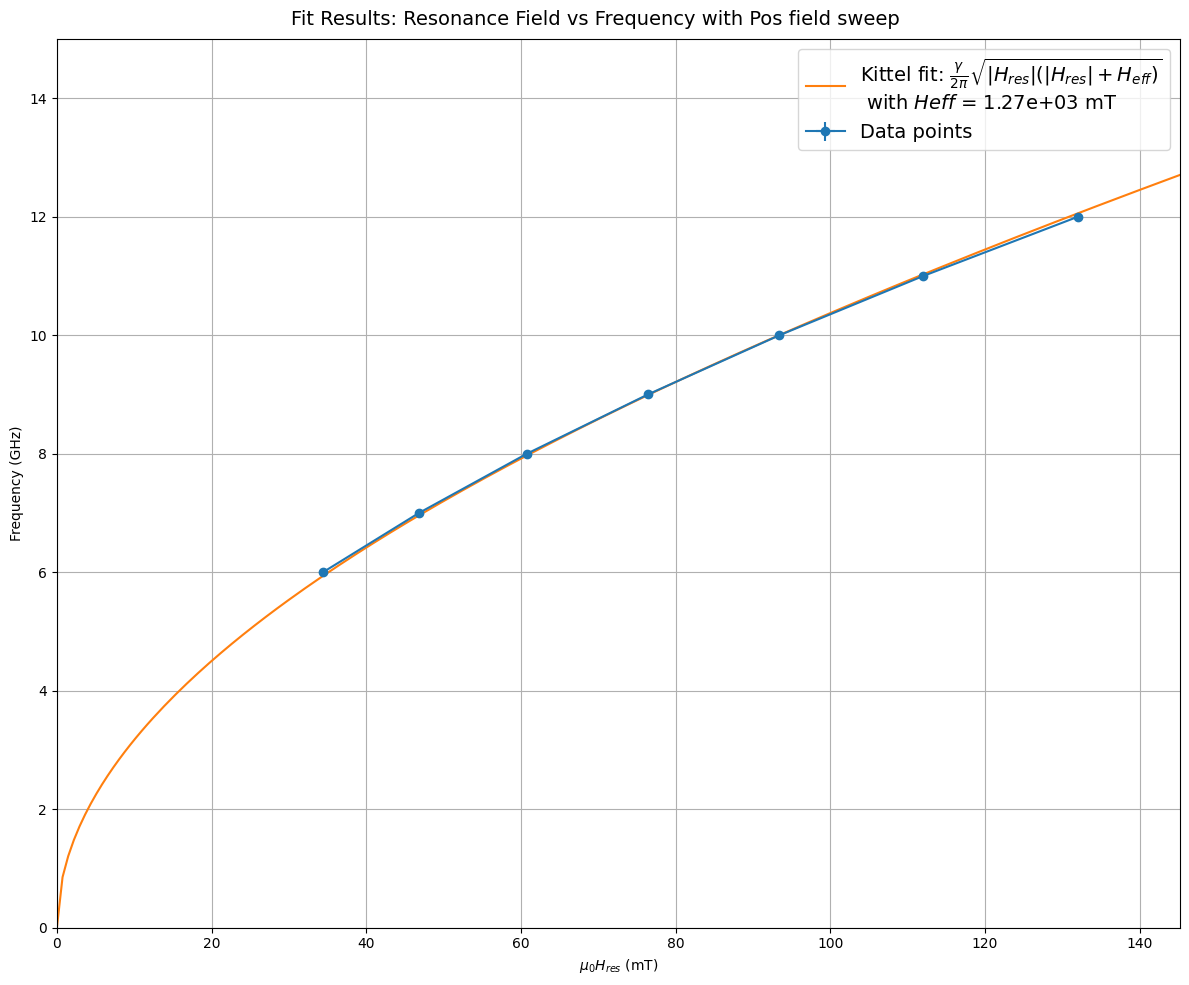

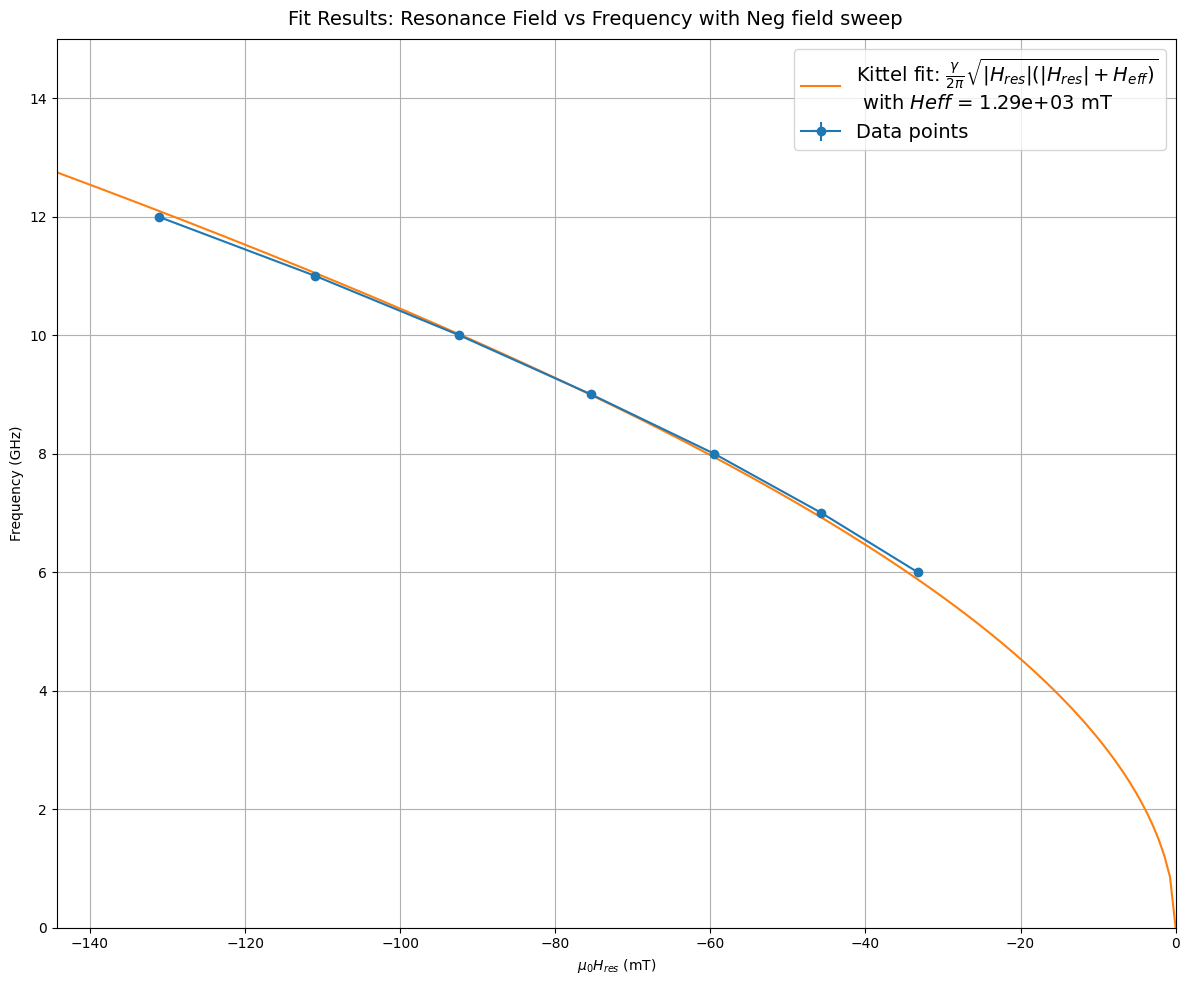

In [13]:
# Frequency Scan - Plotting Kittel

stfmr1 = STFMR(folder=".\\DK158\\FrequencyScan", voltage_unit='uV', d_FM=5e-9, d_NM=5e-9, Ms=1e6, Width=20e-6, Length=40e-6, used_fields='Pos')
stfmr12 = STFMR(folder=".\\DK158\\FrequencyScan", used_fields='Neg')
stfmr2 = STFMR(folder=".\\DK159\\FrequencyScan", used_fields='Pos')
stfmr22 = STFMR(folder=".\\DK159\\FrequencyScan", used_fields='Neg')

# stfmr1.average_fitparams()
# stfmr12.average_fitparams()
# stfmr2.average_fitparams()
# stfmr22.average_fitparams()

stfmr1.plot_Kittel()
stfmr12.plot_Kittel()
# stfmr2.plot_Kittel()
# stfmr22.plot_Kittel()

 return (Vs/Va) * (self.e/self.hbar) * (self.mu_0 * Ms * d_FM * d_NM ) * np.sqrt(1+(((4* np.pi* Meff))/Hres))

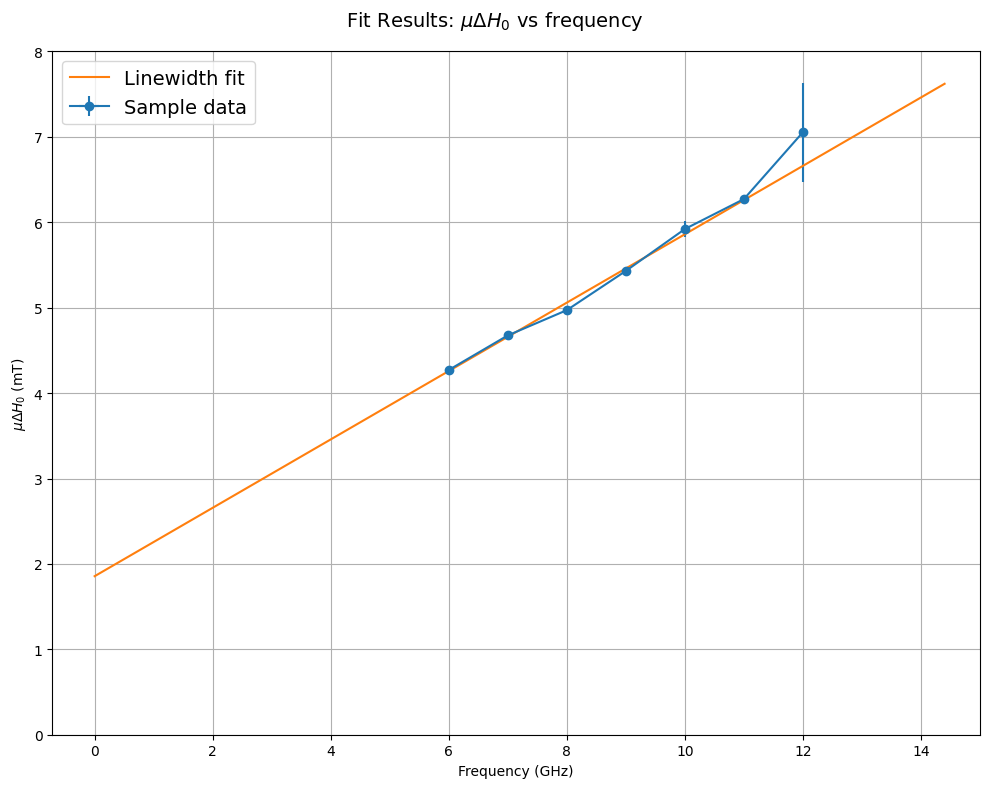

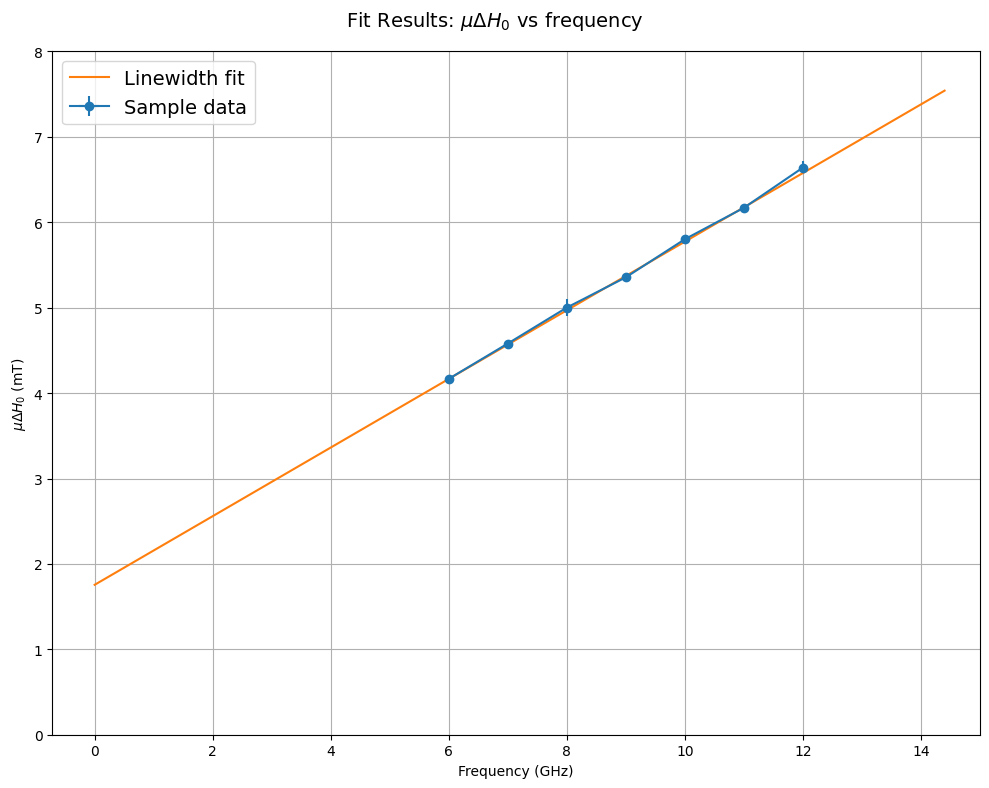

C:\Users\chris\AppData\Local\Temp\ipykernel_17232\3561877716.py:530: OptimizeWarning: Covariance of the parameters could not be estimated
  params, pocv = curve_fit(self.linewidth_formula, df_sorted["freq"]*1e9, df_sorted['Delta']*1e-3, sigma=df_sorted["Deltastd"],p0=[1/self.mu_0, 1])


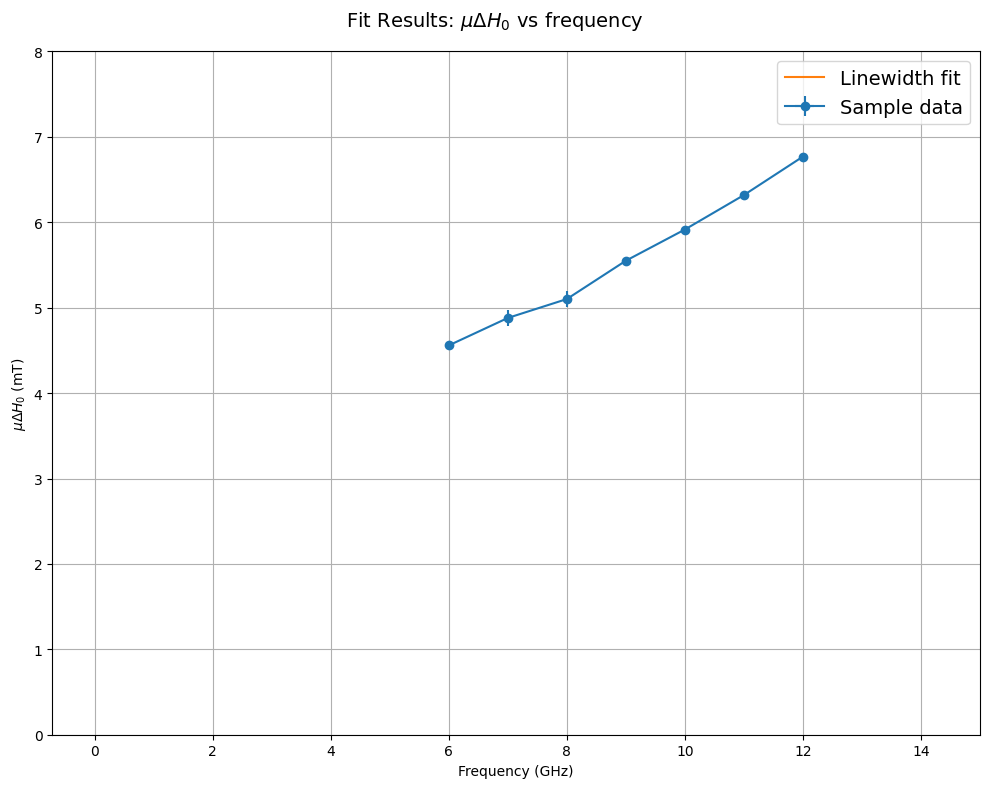

C:\Users\chris\AppData\Local\Temp\ipykernel_17232\3561877716.py:530: OptimizeWarning: Covariance of the parameters could not be estimated
  params, pocv = curve_fit(self.linewidth_formula, df_sorted["freq"]*1e9, df_sorted['Delta']*1e-3, sigma=df_sorted["Deltastd"],p0=[1/self.mu_0, 1])


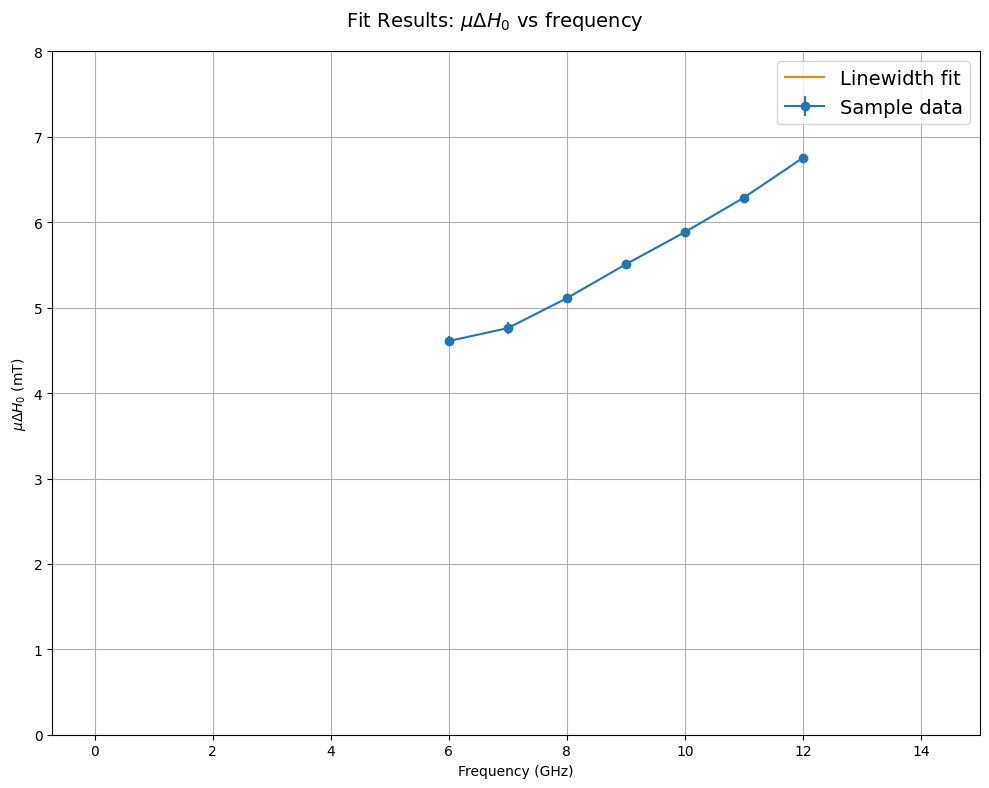

In [128]:
# Frequency Scan - Plotting Linewidth vs frequency

stfmr1 = STFMR(folder=".\\DK158\\FrequencyScan", used_fields='Pos')
stfmr12 = STFMR(folder=".\\DK158\\FrequencyScan", used_fields='Neg')
stfmr2 = STFMR(folder=".\\DK159\\FrequencyScan", used_fields='Pos')
stfmr22 = STFMR(folder=".\\DK159\\FrequencyScan", used_fields='Neg')

# stfmr1.average_fitparams()
# stfmr12.average_fitparams()
# stfmr2.average_fitparams()
# stfmr22.average_fitparams()

stfmr1.plot_linewidth()
stfmr12.plot_linewidth()
stfmr2.plot_linewidth()
stfmr22.plot_linewidth()

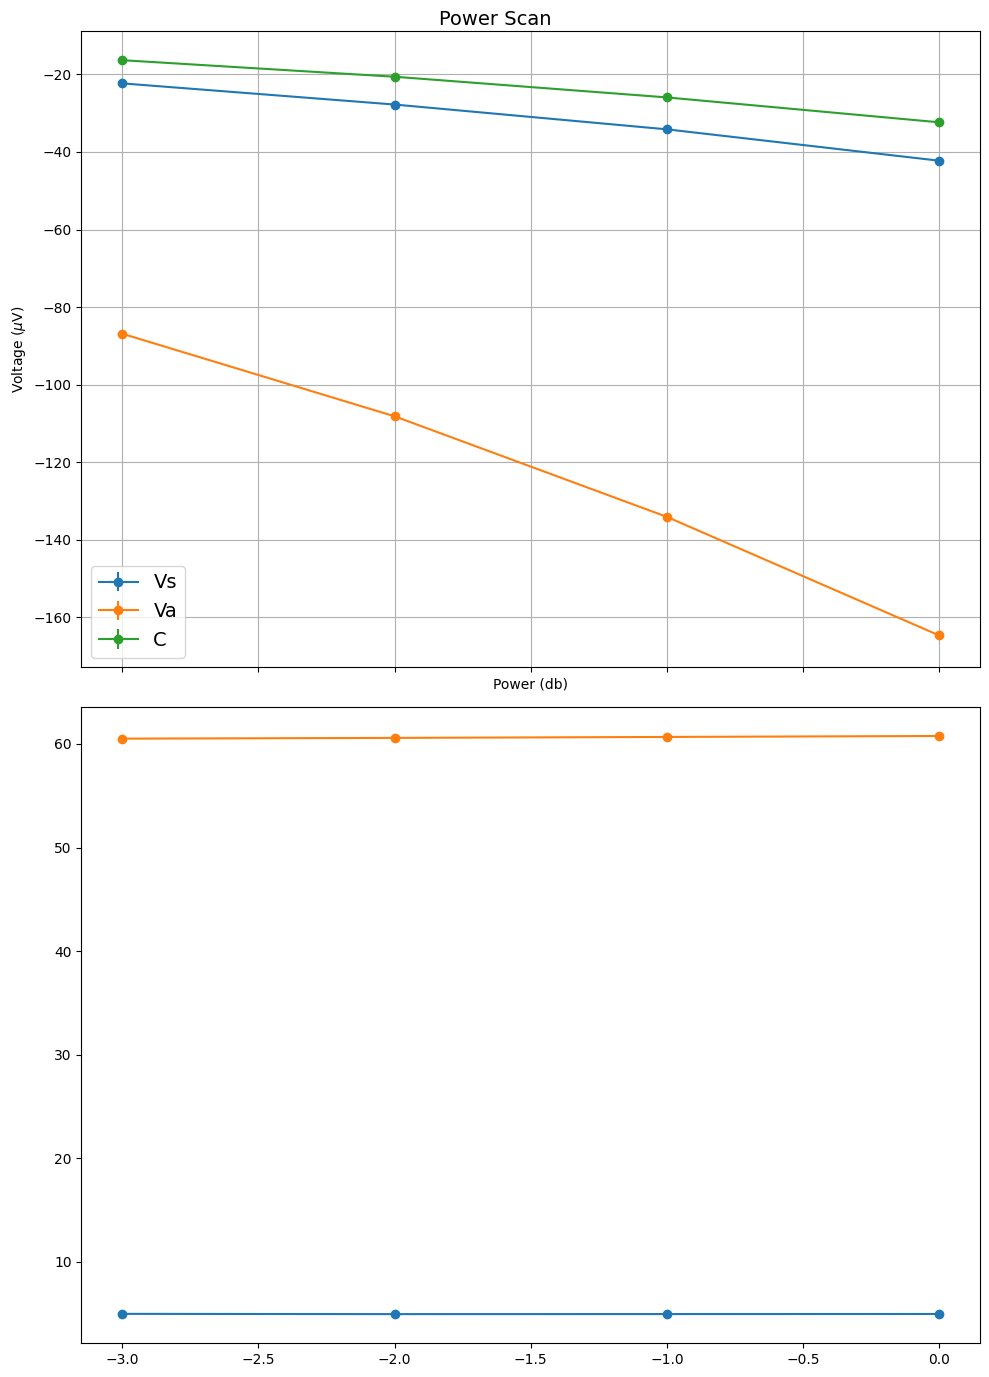

C:\Users\chris\AppData\Local\Temp\ipykernel_1764\1551094496.py:249: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


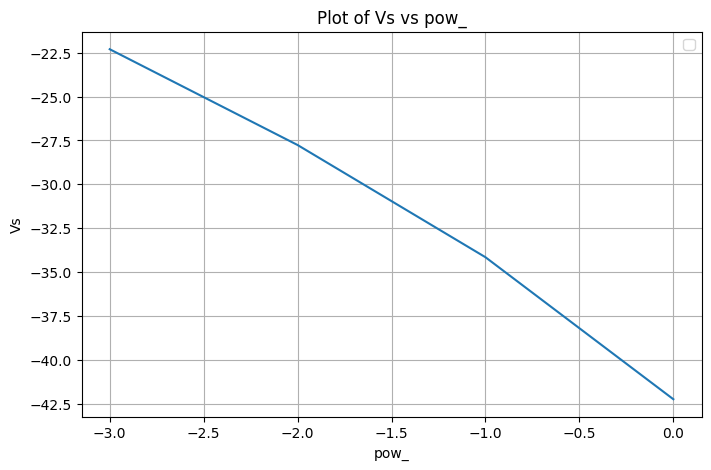

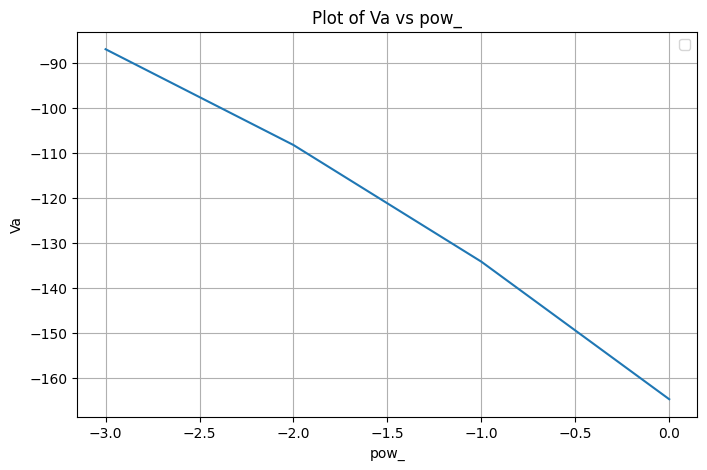

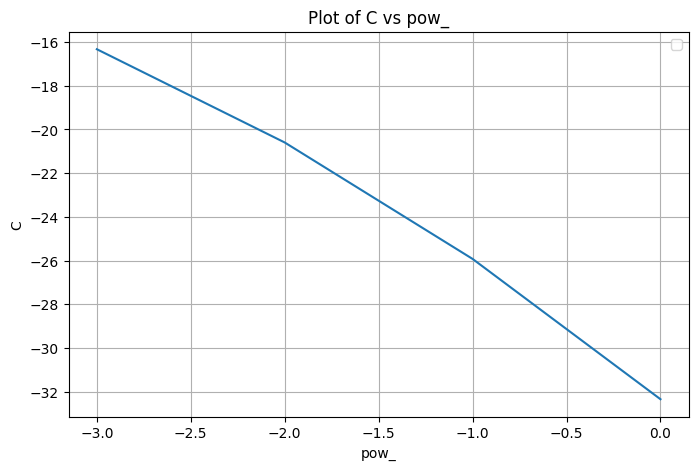

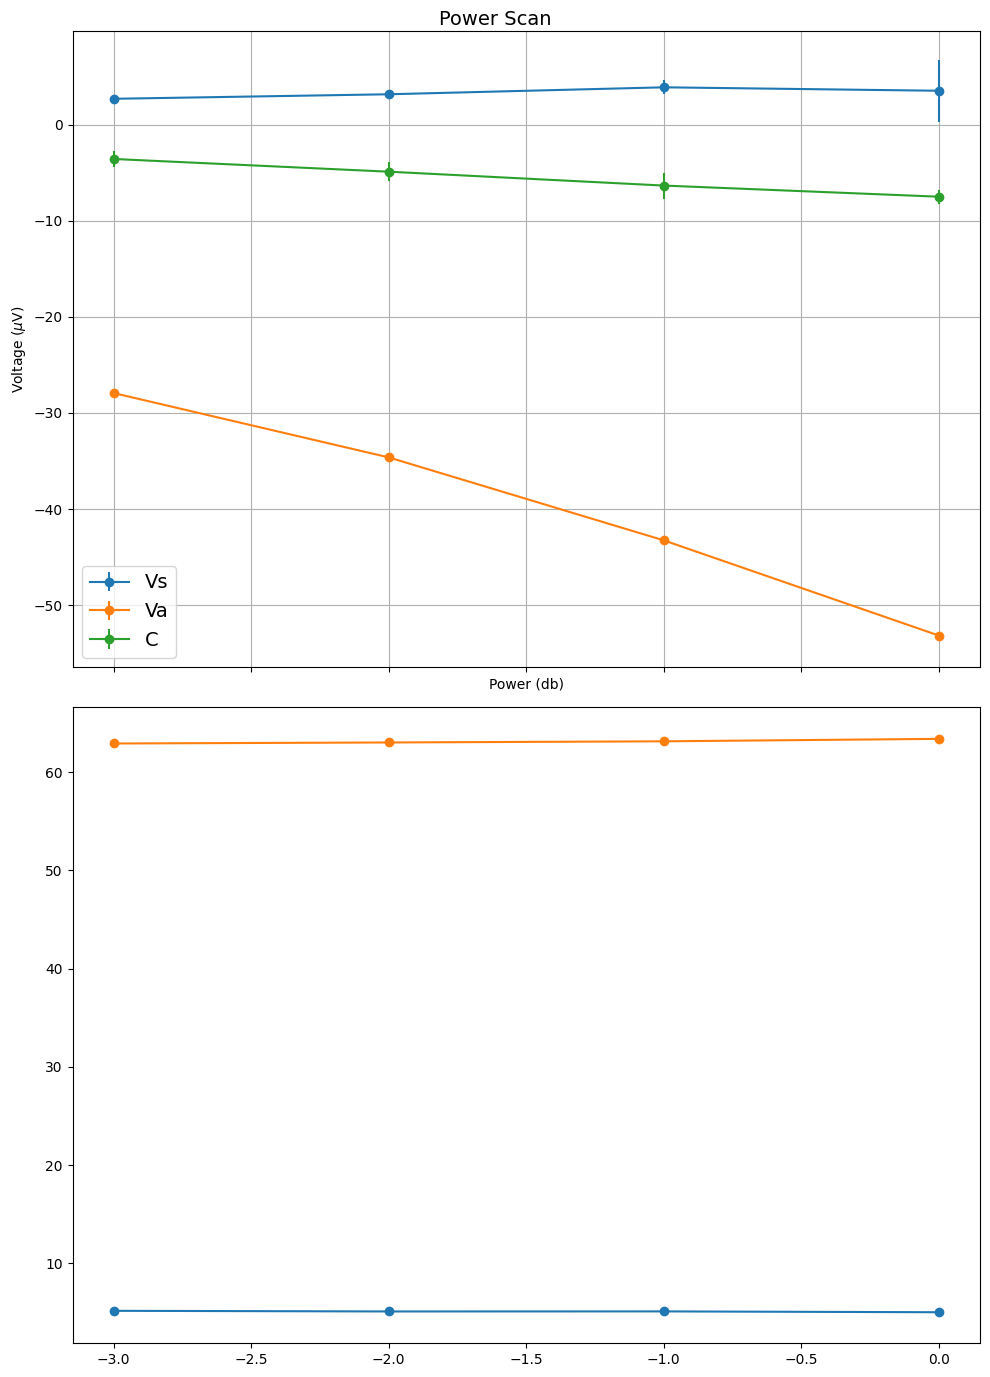

C:\Users\chris\AppData\Local\Temp\ipykernel_1764\1551094496.py:249: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


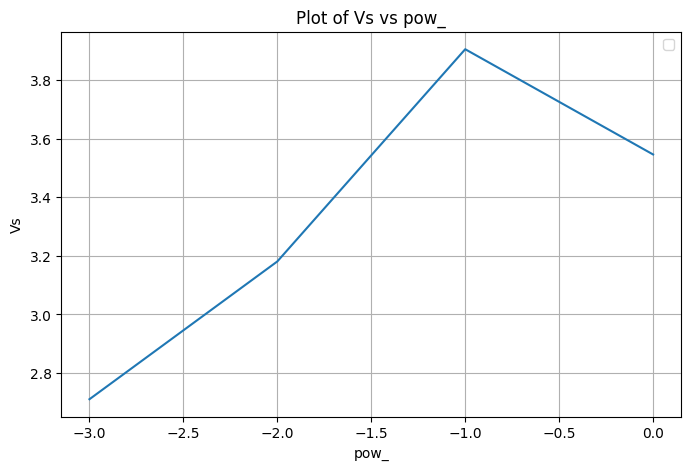

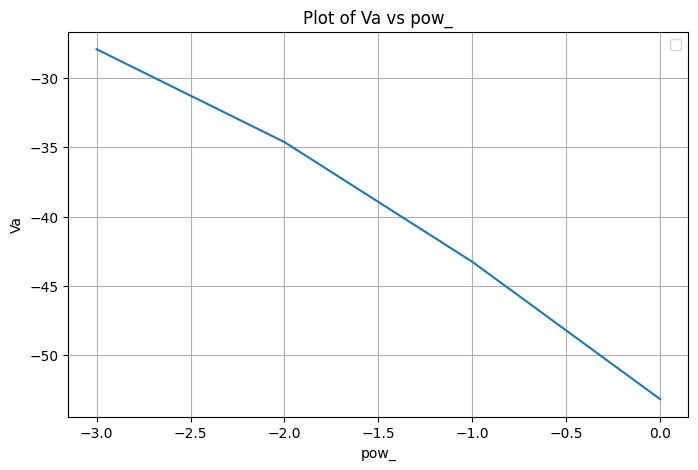

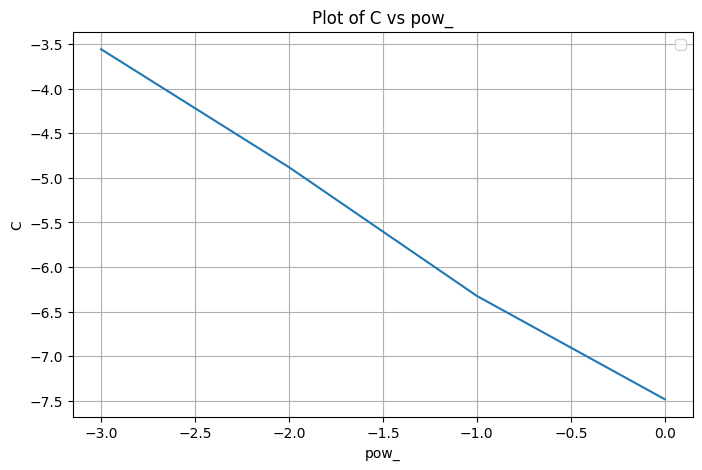

In [14]:
# Power Scan - Plotting power vs Vs, Va
stfmr1 = STFMR(folder=".\\DK158\\PowerScan", used_fields='Pos') # only did positive
stfmr2 = STFMR(folder=".\\DK159\\PowerScan", used_fields='Pos')
# stfmr1.average_fitparams()
# stfmr2.average_fitparams()

stfmr1.plot_power()
stfmr2.plot_power()


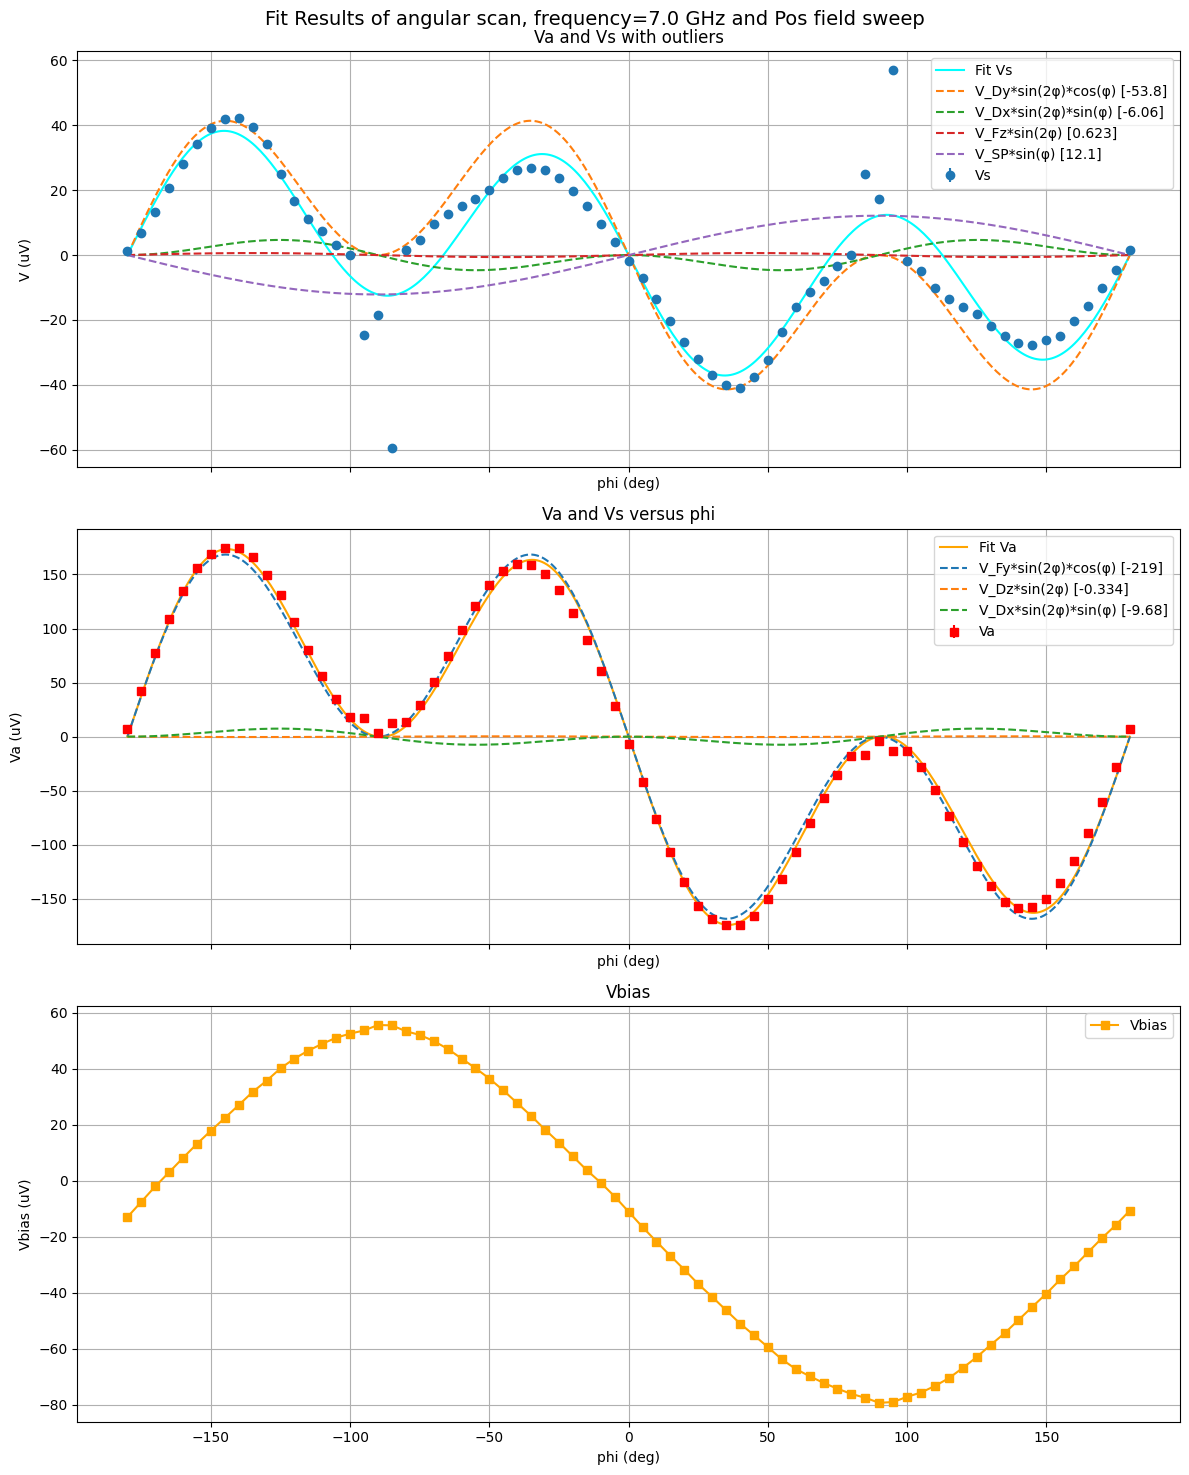

73


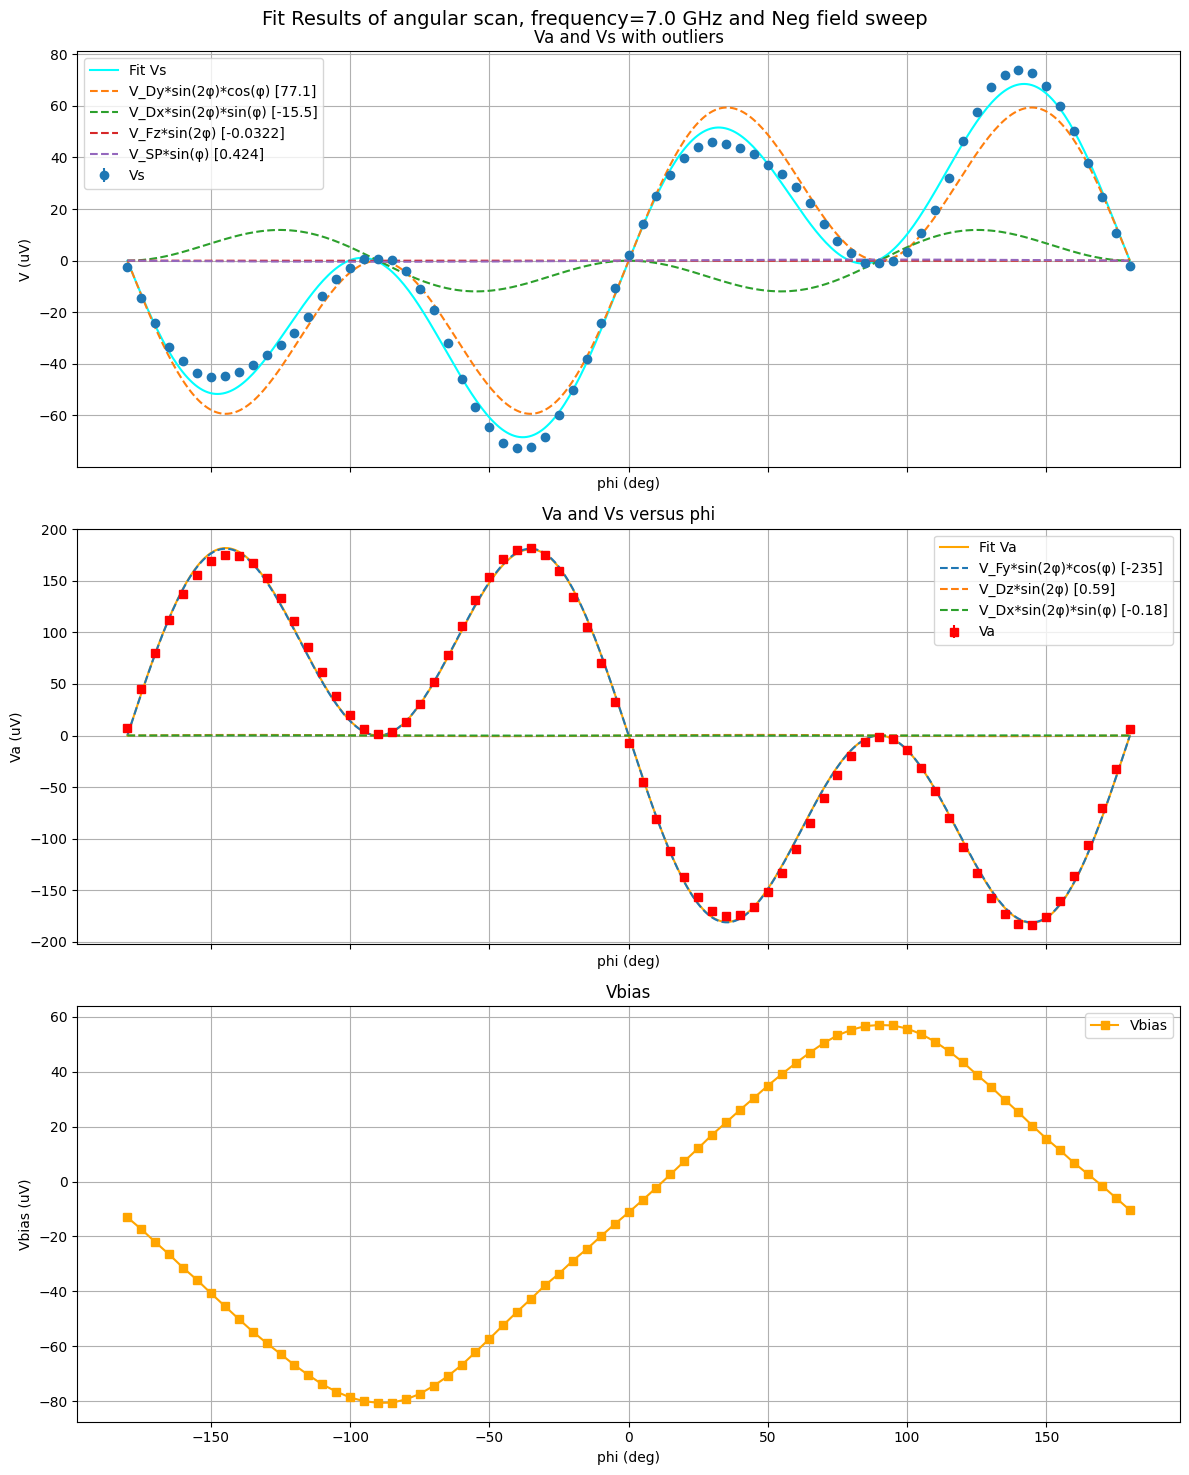

73


In [2]:
# Angular Scan - Plotting Vs, Va, Vb versus angle
folder = ".\\DK158\\AngularScan"

stfmr = STFMR(folder=folder, used_fields='Pos')
stfmr1 = STFMR(folder=folder, used_fields='Neg')

# stfmr.average_traces(plot=False)
# stfmr1.average_traces(plot=True)

# stfmr.analyse_folder(plot=True)
# stfmr1.analyse_folder(plot=True)

# stfmr.average_fitparams()
# stfmr1.average_fitparams()

stfmr.angular_scan()
stfmr1.angular_scan()



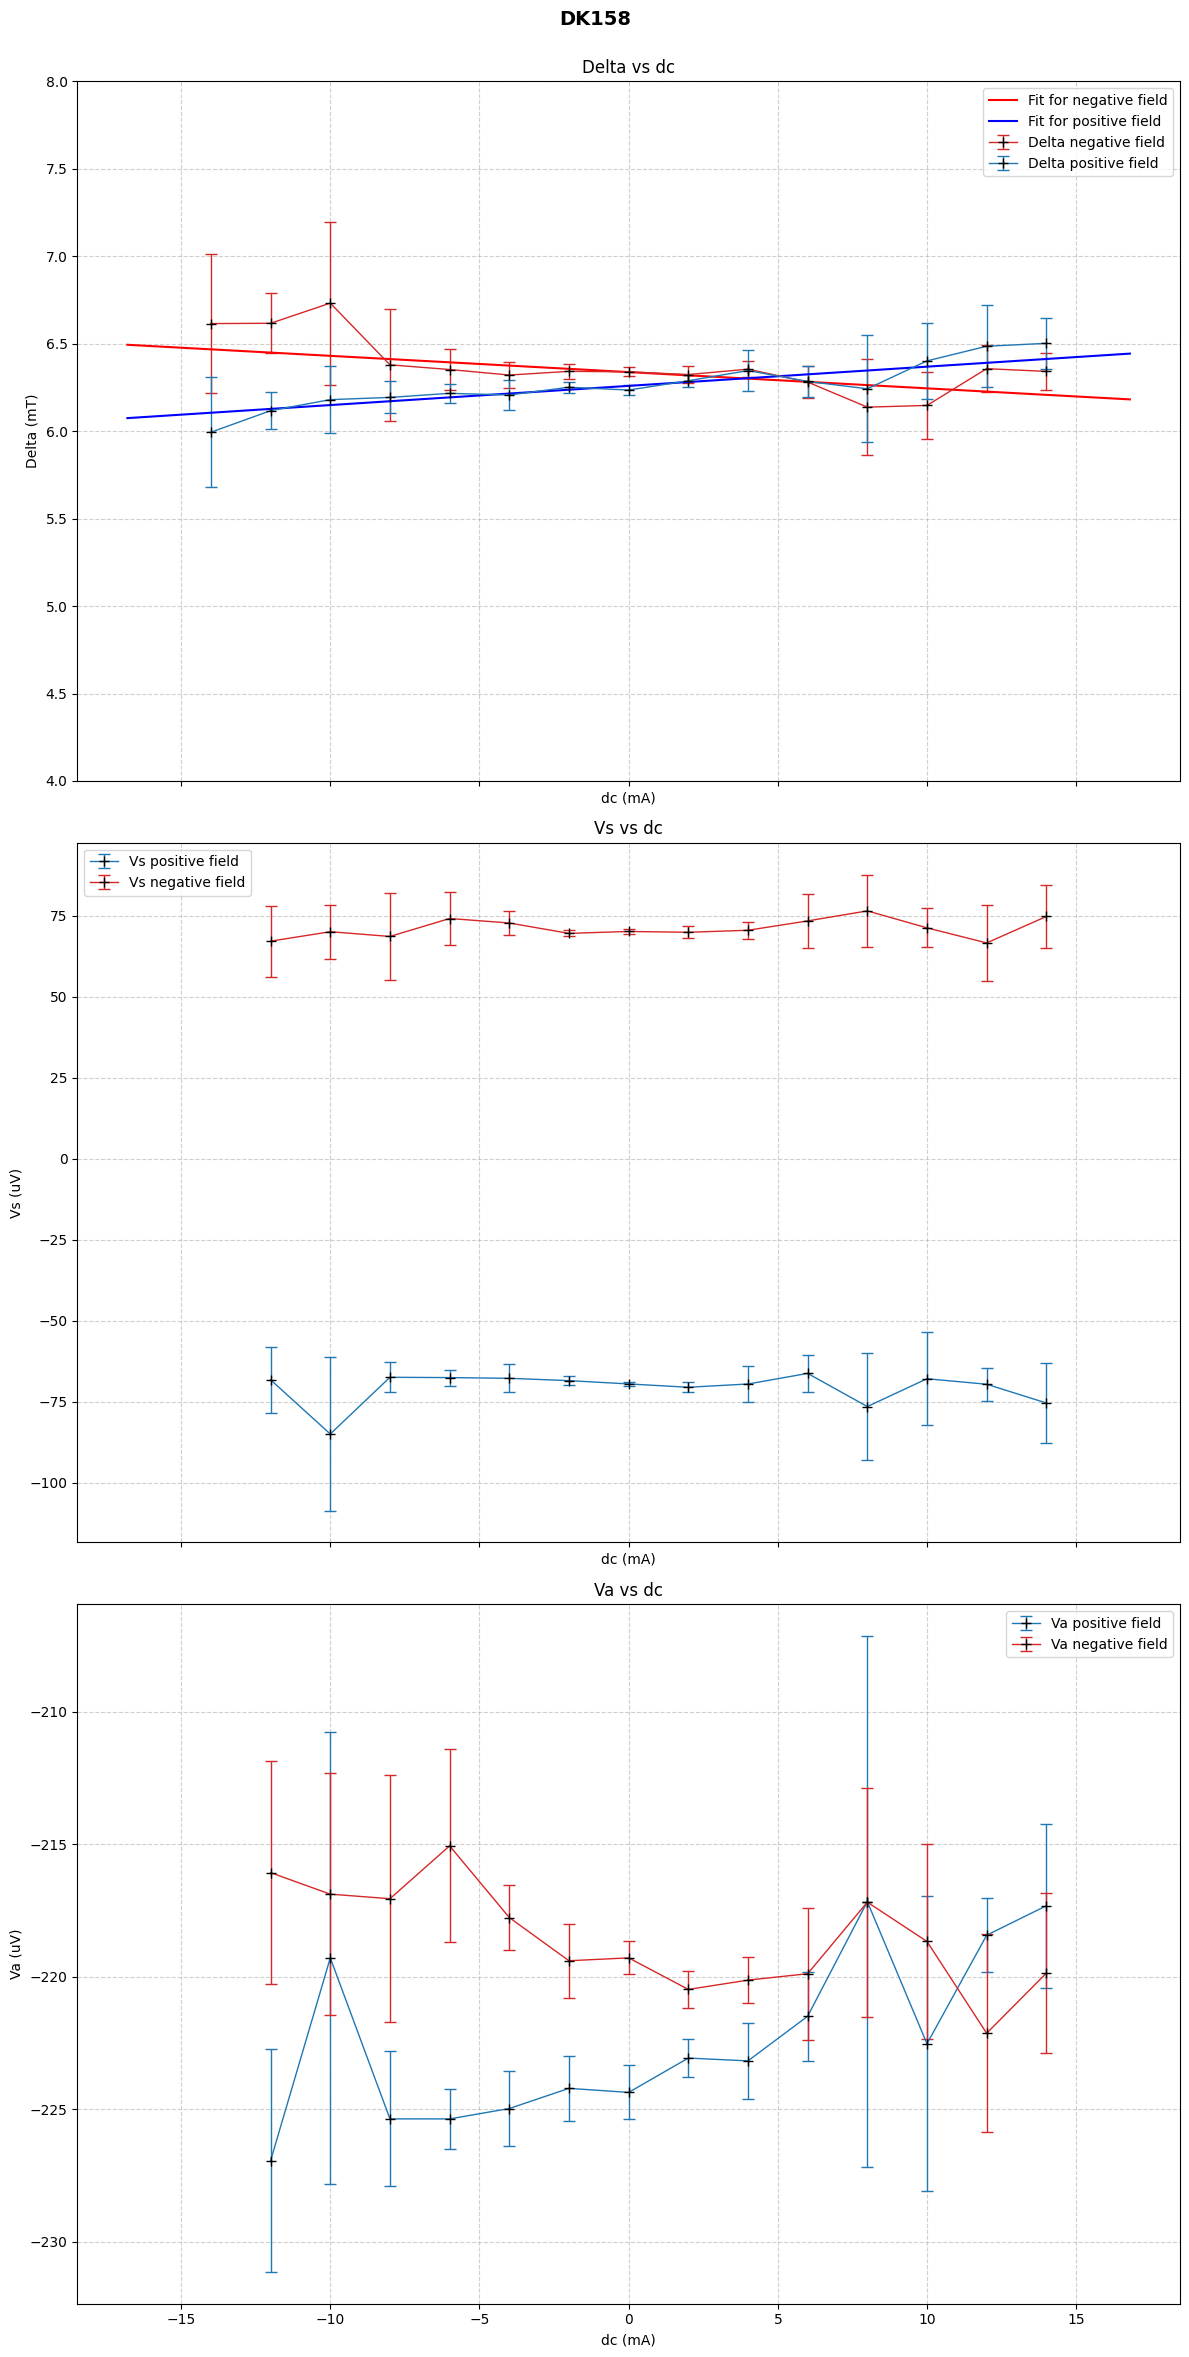

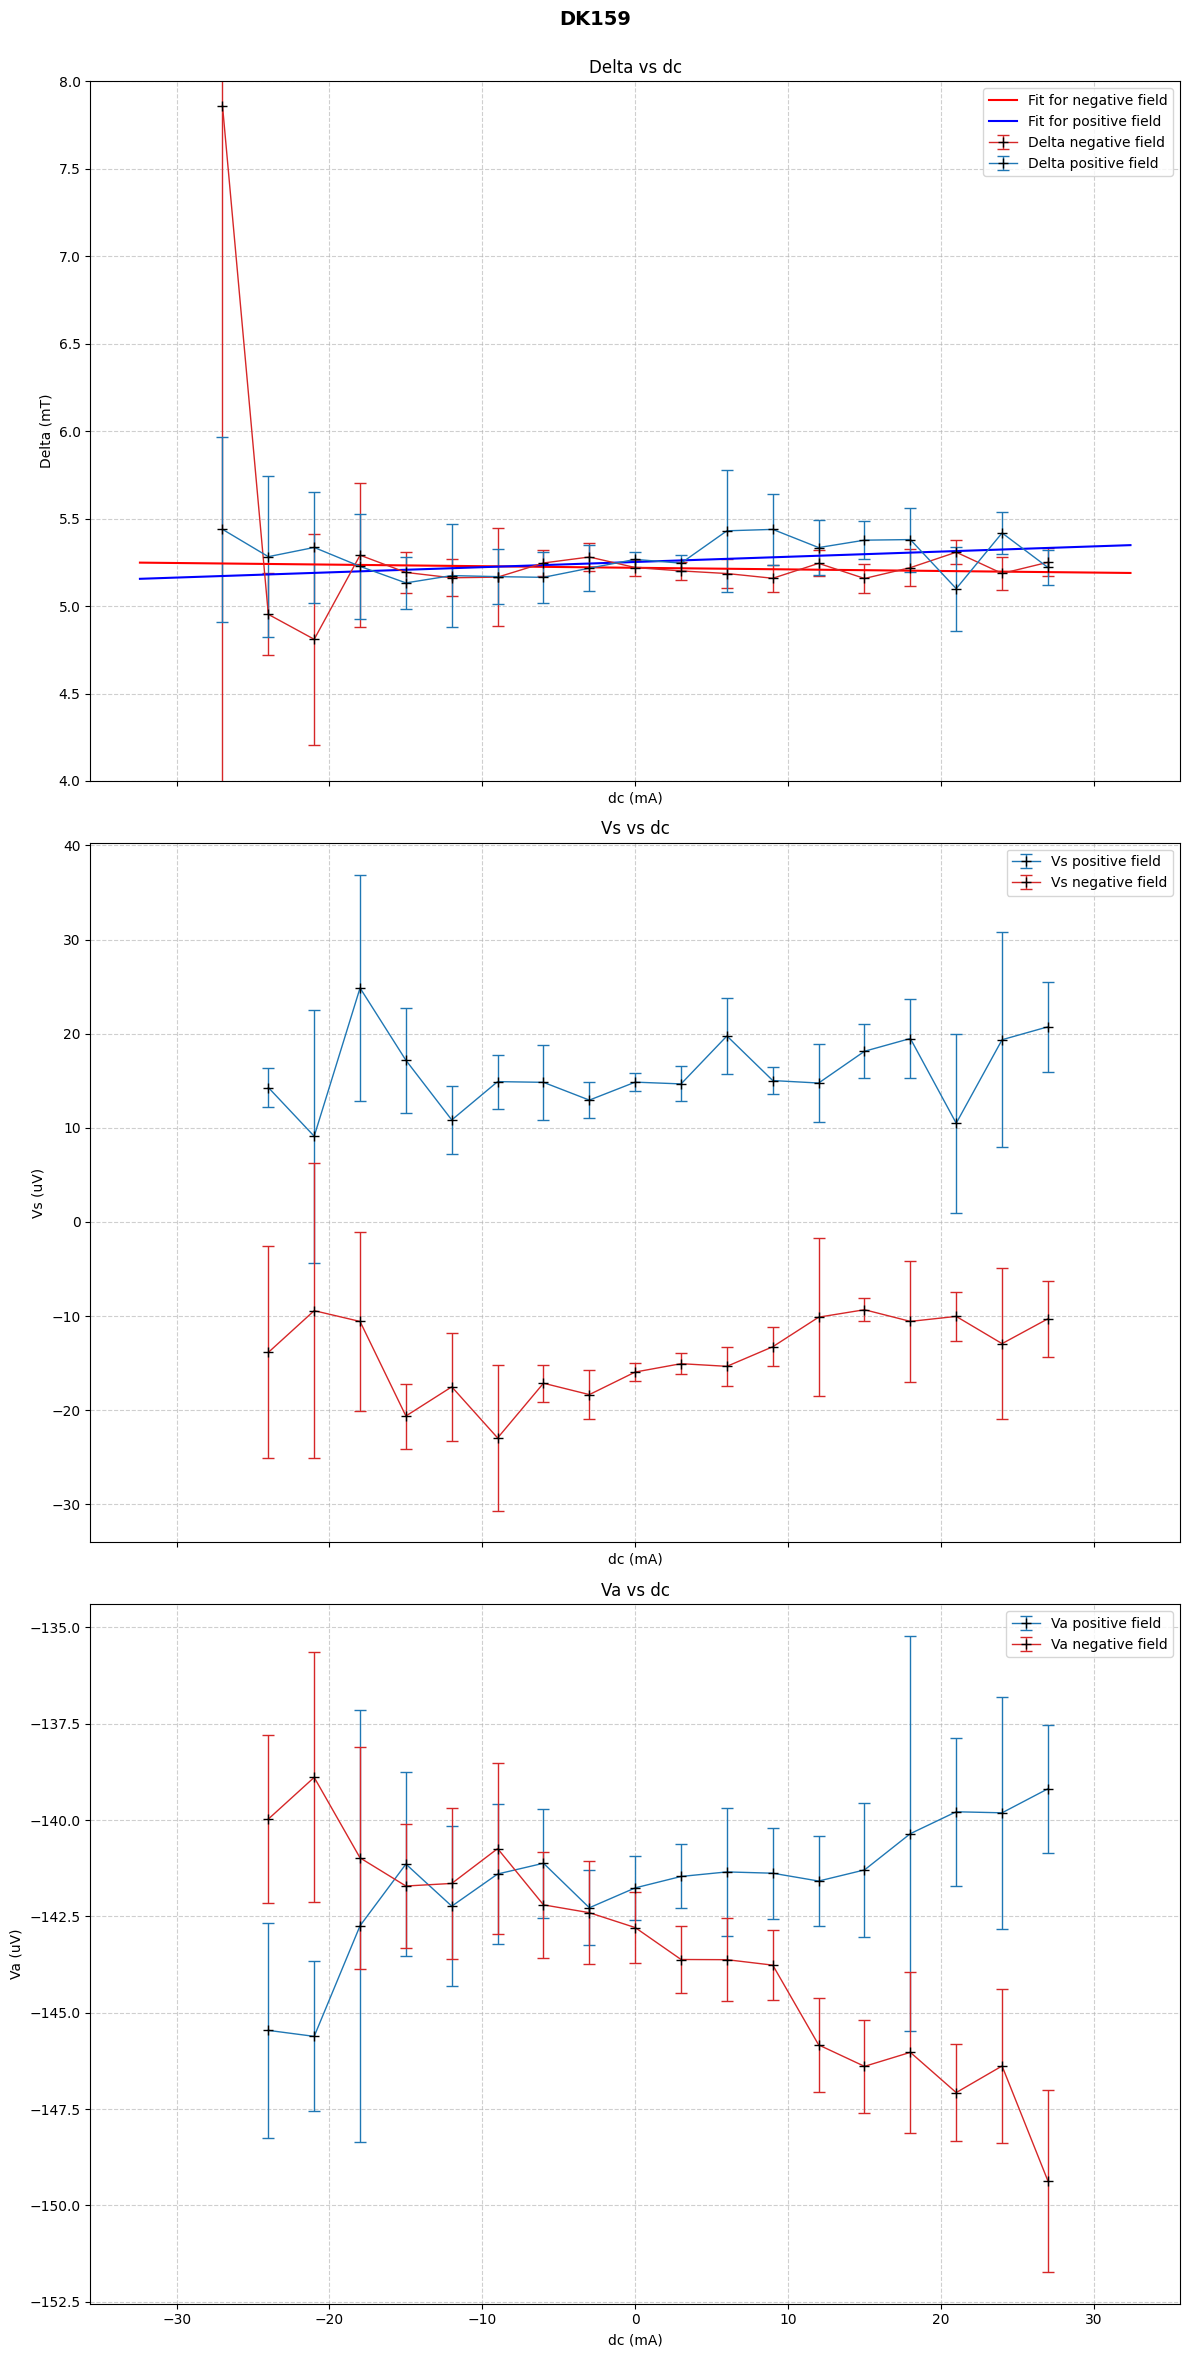

In [ ]:
# DC Scan - plotting linewidth versus DC current 
folder1 = ".\\DK158\\DCScan"
stfmr1 = STFMR(folder=folder1, used_fields='Pos')
stfmr12 = STFMR(folder=folder1, used_fields='Neg')

folder2 = ".\\DK159\\DCScan"
stfmr2 = STFMR(folder=folder2, used_fields='Pos')
stfmr22 = STFMR(folder=folder2, used_fields='Neg')

# stfmr1.plot_traces( used_fields='Pos')
# stfmr22.plot_traces()

# stfmr1.average_traces(plot=True, used_fields='Pos')
# stfmr1.average_traces(plot=True, used_fields='Neg')

# stfmr1.analyse_folder(plot=False, remove_symmetric=True, used_fields= 'Pos')
# stfmr22.analyse_folder(plot=True)

# stfmr1.average_fitparams()
# stfmr12.average_fitparams()

# stfmr2.average_fitparams()
# stfmr22.average_fitparams()

stfmr1.DCScan()
stfmr2.DCScan()


c:\git\MasterProject\.venv\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\git\MasterProject\.venv\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\git\MasterProject\.venv\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\git\MasterProject\.venv\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\git\MasterProject\.venv\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\git\MasterProject\.venv\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value enco

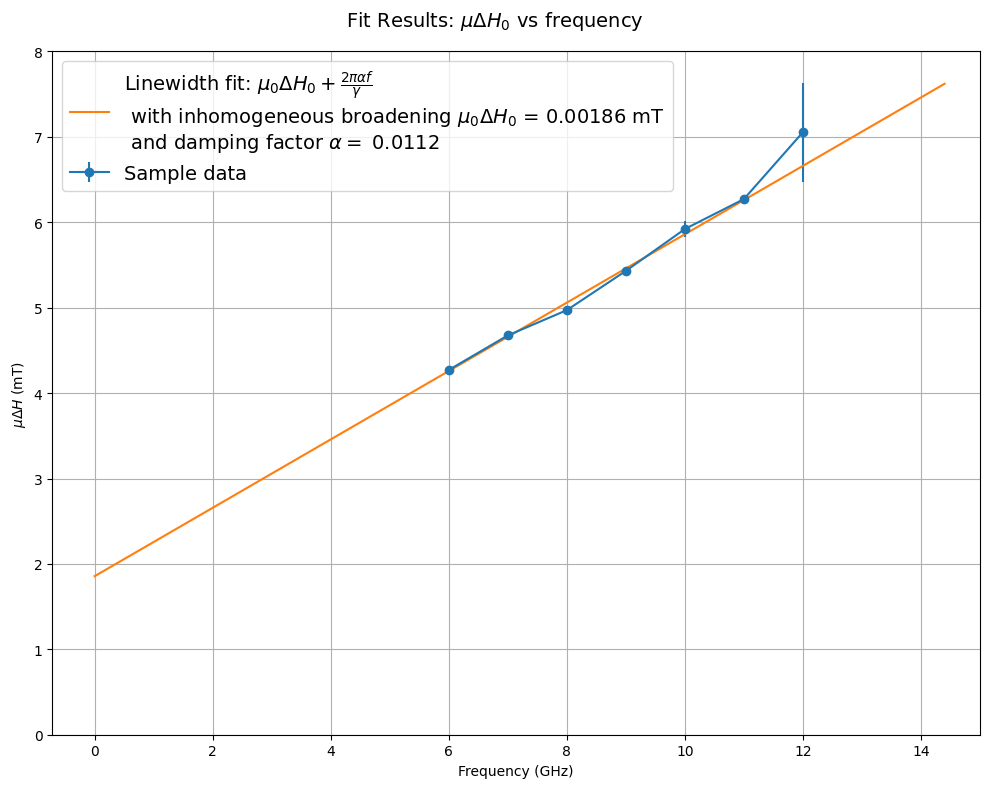

C:\Users\chris\AppData\Local\Temp\ipykernel_17232\2261232900.py:533: OptimizeWarning: Covariance of the parameters could not be estimated
  params, pocv = curve_fit(self.linewidth_formula, df_sorted["freq"]*1e9, df_sorted['Delta']*1e-3, sigma=df_sorted["Deltastd"],p0=[1/self.mu_0, 1])


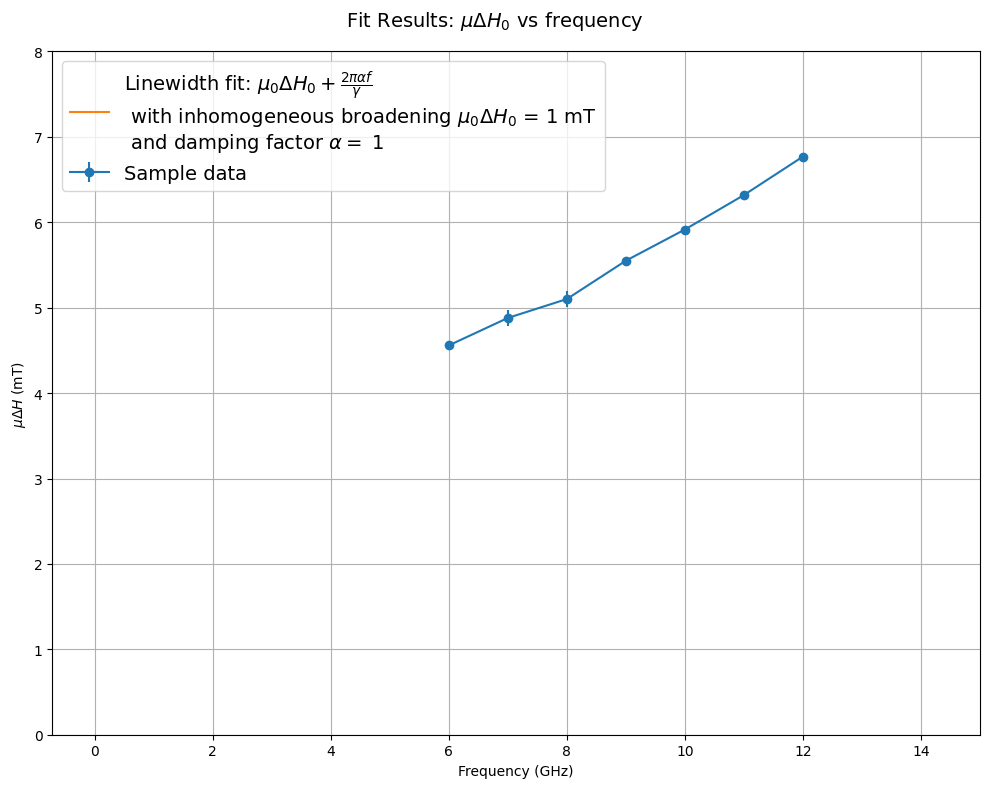

In [ ]:
# Frequncy Scan - Linewidth vs Frequency
folder1 = ".\\DK158\\FrequencyScan"
stfmr1 = STFMR(folder=folder1, used_fields='Pos')
stfmr12 = STFMR(folder=folder1, used_fields='Neg')

folder2 = ".\\DK159\\FrequencyScan"
stfmr2 = STFMR(folder=folder2, used_fields='Pos')
stfmr22 = STFMR(folder=folder2, used_fields='Neg')


# stfmr1.average_fitparams()
# stfmr12.average_fitparams()

stfmr2.average_fitparams()
# stfmr22.average_fitparams()

stfmr1.plot_linewidth()
stfmr2.plot_linewidth()


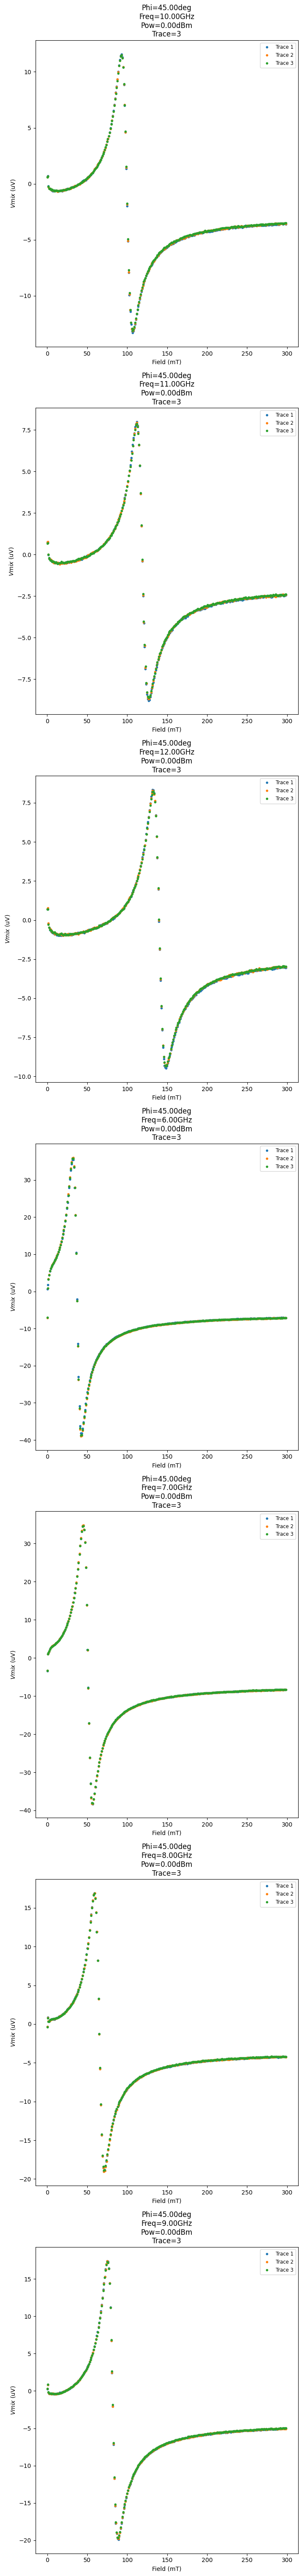

In [11]:
path = r".\\SSN095\\FrequencyScan"
stfmr = STFMR(folder = path, used_fields='Pos')
stfmr.average_fitparams()
stfmr.analyse_folder()
stfmr.plot_traces()